1. Initialize:
   - N_observe = fixed number of particles to observe per step (a+b)
   - B = b_total (total budget)
   - Create reward landscape r(x) with values in [0,1]
   - Initialize CNN f_θ(x) for reward prediction (input: coordinates, output: reward [0,1])
   - Define schedules:
     * a(step) and b(step): top/bottom particle selection (a+b=N_observe, early: small a, large b; late: all a)
     * weight_percentile(step): for sampling particles (early: sample middle weights; late: sample extremes)

2. Baseline Diffusion Model:
   - Define equation: ∂q_t/∂t = -⟨∇, q_t(-f_t + σ_t²∇log q_t)⟩ + (σ_t²/2)Δq_t
   - Define SDE: dx_t = (-f_t(x_t) + σ_t²∇log q_t(x_t))dt + σ_t dW_t
   - Use pretrained score function ∇log q_t(x_t)

3. Feynman-Kac Corrector:
   - Modified SDE: dx_t = σ_t²(∇log q_t(x_t) + (β_t/2)∇r(x_t))dt - f_t(x_t)dt + σ_t dW_t
   - Weight update: dw_t = (∂β_t/∂t)r(x_t)dt - ⟨β_t∇r(x_t), f_t(x_t)⟩dt + ⟨β_t∇r(x_t), (σ_t²/2)∇log q_t(x_t)⟩dt

4. Cold Start (Step 0):
   - Generate N_observe particles using ONLY baseline diffusion (no FKC)
   - Observe ALL particles (get true rewards)
   - Train CNN with (coordinates, rewards) pairs
   - Budget -= N_observe

5. Main Loop (Step 1 onwards, while B > 0):
   a. Generate N particles using FKC with learned reward gradient from CNN (N is fixed)
   b. Calculate weights w for all particles
   c. Epsilon-greedy selection (ε = function of step/total_steps):
      - With probability ε: select k particles randomly
      - With probability 1-ε: select top k particles by weight
      - ε decreases from high (e.g., 0.8) to low (e.g., 0.1) as steps progress
   d. Observe true rewards for selected k particles (k is fixed)
   e. Update CNN with new observations (coordinates → actual reward values)
   f. Calculate success rate
   g. Budget -= k
   h. Visualize results

6. Final visualization:
   - Learned reward landscape (from CNN) vs particles (color by weights)
   - True reward landscape vs observed particles (color by true rewards)
   - Success rate evolution

import

In [26]:
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple, Dict, Any
import optax
from functools import partial

# Set random seed for reproducibility
jax.config.update("jax_enable_x64", True)

reward

In [27]:
def create_reward_landscape(x: jnp.ndarray) -> jnp.ndarray:
    """
    Create a synthetic reward landscape with values in [0,1].
    This is the 'true' reward function that we're trying to learn.
    """
    # BULLETPROOF: Handle any input shape
    original_shape = x.shape
    
    # Ensure we have a 2D array (batch_size, 2)
    if x.ndim == 1:
        x = x.reshape(-1, 2)
        squeeze_output = True
    elif x.ndim == 2:
        squeeze_output = False
    else:
        # Flatten all but last dimension
        x = x.reshape(-1, x.shape[-1])
        squeeze_output = False
    
    # DEBUG: Print shape info
    print(f"    Reward function input shape: {original_shape} -> {x.shape}")
    
    # Initialize reward as JAX array with correct shape
    reward = jnp.zeros(x.shape[0])
    
    # Add multiple Gaussian peaks
    peaks = [(0.3, 0.7), (0.7, 0.3), (0.5, 0.5)]
    for peak_x, peak_y in peaks:
        # Calculate distance for each particle
        dist = jnp.sqrt((x[:, 0] - peak_x)**2 + (x[:, 1] - peak_y)**2)
        # Add to reward (both should have shape (batch_size,))
        reward = reward + jnp.exp(-dist**2 / 0.1)
    
    # Ensure [0,1] range
    reward = jnp.clip(reward, 0, 1)
    
    # Reshape back to original shape if needed
    if squeeze_output and original_shape == (2,):
        reward = reward.squeeze()
    elif original_shape != x.shape:
        reward = reward.reshape(original_shape[:-1])
    
    print(f"    Reward function output shape: {reward.shape}")
    return reward

def reward_landscape_gradient(x: jnp.ndarray) -> jnp.ndarray:
    """Compute gradient of reward landscape using JAX autodiff."""
    if x.ndim == 1:
        return jax.grad(create_reward_landscape)(x)
    else:
        # For batch of particles, use vmap
        grad_fn = jax.grad(create_reward_landscape)
        return jax.vmap(grad_fn)(x)

def create_four_optima_reward_landscape(x: jnp.ndarray) -> jnp.ndarray:
    """
    Create reward landscape with four global optima in four quadrants.
    Peaks at approximately (0.25, 0.25), (0.75, 0.25), (0.25, 0.75), (0.75, 0.75)
    """
    # BULLETPROOF: Handle any input shape
    original_shape = x.shape
    
    # Ensure we have a 2D array (batch_size, 2)
    if x.ndim == 1:
        x = x.reshape(-1, 2)
        squeeze_output = True
    elif x.ndim == 2:
        squeeze_output = False
    else:
        # Flatten all but last dimension
        x = x.reshape(-1, x.shape[-1])
        squeeze_output = False
    
    # DEBUG: Print shape info
    print(f"    Four optima reward function input shape: {original_shape} -> {x.shape}")
    
    # Initialize reward as JAX array with correct shape
    reward = jnp.zeros(x.shape[0])
    
    # Four equal peaks in four quadrants
    peaks = [(0.25, 0.25), (0.75, 0.25), (0.25, 0.75), (0.75, 0.75)]
    for peak_x, peak_y in peaks:
        dist = jnp.sqrt((x[:, 0] - peak_x)**2 + (x[:, 1] - peak_y)**2)
        reward = reward + jnp.exp(-dist**2 / 0.05)  # Narrower peaks
    
    # FIXED: Don't normalize by 4, let peaks reach higher values
    # reward = reward / 4.0  # Remove this line!
    reward = jnp.clip(reward, 0, 1)  # Just clip to [0,1]
    
    # Reshape back to original shape if needed
    if squeeze_output and original_shape == (2,):
        reward = reward.squeeze()
    elif original_shape != x.shape:
        reward = reward.reshape(original_shape[:-1])
    
    print(f"    Four optima reward function output shape: {reward.shape}")
    return reward

def four_optima_reward_gradient(x: jnp.ndarray) -> jnp.ndarray:
    """Compute gradient of four optima reward landscape."""
    if x.ndim == 1:
        return jax.grad(create_four_optima_reward_landscape)(x)
    else:
        grad_fn = jax.grad(create_four_optima_reward_landscape)
        return jax.vmap(grad_fn)(x)

baseline diffusion model

In [28]:
def baseline_score_function(x: jnp.ndarray, t: float) -> jnp.ndarray:
    """
    Pretrained score function for baseline diffusion.
    This is a simple Gaussian score function for demonstration.
    """
    # Simple Gaussian target distribution
    mean = jnp.array([0.5, 0.5])
    sigma = 0.3
    
    # Handle both single particle and batch
    if x.ndim == 1:
        score = -(x - mean) / (sigma**2)
    else:  # Batch of particles
        score = -(x - mean[None, :]) / (sigma**2)
    
    return score

def baseline_drift(x: jnp.ndarray, t: float) -> jnp.ndarray:
    """Deterministic drift term f_t(x_t) for baseline diffusion."""
    # Return zeros with the same shape as input
    return jnp.zeros_like(x)

def diffusion_coefficient(t: float) -> float:
    """Time-dependent diffusion coefficient σ_t."""
    return 0.1 * (1 - t)  # Decreases from 0.1 to 0

def baseline_sde_step(x: jnp.ndarray, t: float, dt: float, key: jnp.ndarray) -> jnp.ndarray:
    """
    Single step of baseline SDE: dx_t = (-f_t(x_t) + σ_t²∇log q_t(x_t))dt + σ_t dW_t
    """
    sigma_t = diffusion_coefficient(t)
    score = baseline_score_function(x, t)
    drift = -baseline_drift(x, t) + sigma_t**2 * score
    noise = sigma_t * random.normal(key, x.shape)
    
    # Use absolute value of dt for noise scaling since we go backwards in time
    return x + drift * dt + noise * jnp.sqrt(jnp.abs(dt))  # FIXED: use abs(dt)

feynman-kac corrector

In [29]:
def feynman_kac_sde_step(x: jnp.ndarray, w: jnp.ndarray, t: float, dt: float, 
                         reward_grad_fn, beta_t: float, key: jnp.ndarray, 
                         network, network_params) -> Tuple[jnp.ndarray, jnp.ndarray]:  # Add network params
    """
    Single step of Feynman-Kac corrected SDE with numerical stability.
    
    Equation 29: dx_t = σ_t²(∇log q_t(x_t) + (β_t/2)∇r(x_t))dt - f_t(x_t)dt + σ_t dW_t
    Equation 30: dw_t = (∂β_t/∂t)r(x_t)dt - ⟨β_t∇r(x_t), f_t(x_t)⟩dt + ⟨β_t∇r(x_t), (σ_t²/2)∇log q_t(x_t)⟩dt
    """
    sigma_t = diffusion_coefficient(t)
    score = baseline_score_function(x, t)
    reward_grad = reward_grad_fn(x)
    
    # Equation 29: Update particle position
    drift = sigma_t**2 * (score + (beta_t / 2) * reward_grad) - baseline_drift(x, t)
    noise = sigma_t * random.normal(key, x.shape)
    x_new = x + drift * dt + noise * jnp.sqrt(jnp.abs(dt))  # Use abs(dt) here too
    
    # Equation 30: Update weight with numerical stability
    # FIXED: Use CNN predicted reward, not true reward function
    predicted_reward = network['forward'](network_params, x)
    beta_dot = 1.0  # ∂β_t/∂t = 1 (constant beta_t)
    
    # Handle vectorized operations for batch of particles
    if x.ndim == 2:  # Batch of particles
        # Term 1: (∂β_t/∂t)r(x_t)dt
        term1 = beta_dot * predicted_reward * dt
        
        # Term 2: -⟨β_t∇r(x_t), f_t(x_t)⟩dt
        f_t = baseline_drift(x, t)
        term2 = -jnp.sum(beta_t * reward_grad * f_t, axis=1) * dt
        
        # Term 3: +⟨β_t∇r(x_t), (σ_t²/2)∇log q_t(x_t)⟩dt
        term3 = jnp.sum(beta_t * reward_grad * (sigma_t**2 / 2) * score, axis=1) * dt
        
        # Combine all terms
        dw = term1 + term2 + term3
        
    else:  # Single particle
        # Term 1: (∂β_t/∂t)r(x_t)dt
        term1 = beta_dot * predicted_reward * dt
        
        # Term 2: -⟨β_t∇r(x_t), f_t(x_t)⟩dt
        f_t = baseline_drift(x, t)
        term2 = -jnp.dot(beta_t * reward_grad, f_t) * dt
        
        # Term 3: +⟨β_t∇r(x_t), (σ_t²/2)∇log q_t(x_t)⟩dt
        term3 = jnp.dot(beta_t * reward_grad, (sigma_t**2 / 2) * score) * dt
        
        # Combine all terms
        dw = term1 + term2 + term3
    
    # Add numerical stability to weight updates
    # Clip dw to prevent extreme changes
    dw = jnp.clip(dw, -0.1, 0.1)  # Limit weight changes per step
    
    # Update weights
    w_new = w + dw
    
    # Ensure weights stay positive and bounded
    w_new = jnp.clip(w_new, 0.1, 10.0)
    
    return x_new, w_new

def run_fkc_simulation(particles: jnp.ndarray, weights: jnp.ndarray, 
                      reward_grad_fn, beta_t: float, n_steps: int, key: jnp.ndarray,
                      network, network_params) -> Tuple[jnp.ndarray, jnp.ndarray]:  # Add network params
    """Run FKC simulation from t=1 to t=0."""
    dt = -1.0 / n_steps  # Negative because we go from t=1 to t=0
    
    for i in range(n_steps):
        t = 1.0 + i * dt
        key, subkey = random.split(key)
        particles, weights = feynman_kac_sde_step(particles, weights, t, dt, 
                                                reward_grad_fn, beta_t, subkey, 
                                                network, network_params)
        
        # Check for numerical issues and fix immediately
        if jnp.any(jnp.isnan(weights)) or jnp.any(jnp.isinf(weights)):
            weights = jnp.where(jnp.isnan(weights) | jnp.isinf(weights), 1.0, weights)
        
        # Also check for NaN particles
        if jnp.any(jnp.isnan(particles)) or jnp.any(jnp.isinf(particles)):
            print(f"  WARNING: NaN particles detected at step {i}, clipping...")
            particles = jnp.where(jnp.isnan(particles) | jnp.isinf(particles), 
                                jnp.clip(particles, 0, 1), particles)
    
    return particles, weights

reward learning neural network

In [30]:
def create_cnn_reward_network():
    """
    Create a CNN for reward prediction that treats 2D coordinates as spatial features.
    """
    def init_fn(key):
        """Initialize CNN parameters."""
        params = {}
        
        # Feature expansion layer: 2 -> 32
        key, subkey = random.split(key)
        params['expand_W'] = random.normal(subkey, (2, 32)) * 0.1
        params['expand_b'] = jnp.zeros(32)
        
        # Conv layers (we'll simulate with dense layers on feature representations)
        key, subkey = random.split(key)
        params['conv1_W'] = random.normal(subkey, (32, 64)) * 0.1
        params['conv1_b'] = jnp.zeros(64)
        
        key, subkey = random.split(key)
        params['conv2_W'] = random.normal(subkey, (64, 64)) * 0.1
        params['conv2_b'] = jnp.zeros(64)
        
        # Fully connected layers
        key, subkey = random.split(key)
        params['fc1_W'] = random.normal(subkey, (64, 32)) * 0.1
        params['fc1_b'] = jnp.zeros(32)
        
        key, subkey = random.split(key)
        params['fc2_W'] = random.normal(subkey, (32, 1)) * 0.1
        params['fc2_b'] = jnp.zeros(1)
        
        return params
    
    def forward(params, x):
        """Forward pass through CNN."""
        # Handle both single particle and batch
        if x.ndim == 1:
            x = x.reshape(1, -1)
            squeeze_output = True
        else:
            squeeze_output = False
        
        # DEBUG: Print input shape
        print(f"    CNN input shape: {x.shape}")
        
        # Feature expansion
        h = jnp.dot(x, params['expand_W']) + params['expand_b']
        h = jax.nn.relu(h)
        
        # Conv-like layer 1
        h = jnp.dot(h, params['conv1_W']) + params['conv1_b']
        h = jax.nn.relu(h)
        
        # Conv-like layer 2
        h = jnp.dot(h, params['conv2_W']) + params['conv2_b']
        h = jax.nn.relu(h)
        
        # Fully connected layer 1
        h = jnp.dot(h, params['fc1_W']) + params['fc1_b']
        h = jax.nn.relu(h)
        
        # Output layer: predict actual reward value [0,1]
        h = jnp.dot(h, params['fc2_W']) + params['fc2_b']
        h = jax.nn.sigmoid(h)  # Output in [0,1]
        
        # DEBUG: Print output shape before squeezing
        print(f"    CNN output shape before squeeze: {h.shape}")
        
        # CRITICAL FIX: Ensure output is 1D for batch inputs
        if h.ndim > 1 and h.shape[-1] == 1:
            h = h.squeeze(-1)  # Remove the last dimension if it's 1
        
        if squeeze_output:
            h = h.squeeze()
        
        # DEBUG: Print final output shape
        print(f"    CNN final output shape: {h.shape}")
        
        return h
    
    return {'init': init_fn, 'forward': forward}

def update_network(network, params, optimizer, opt_state, x_batch, y_batch):
    """Update neural network parameters using observed rewards."""
    def loss_fn(params):
        predictions = network['forward'](params, x_batch)
        
        # DEBUG: Print shapes in loss function
        print(f"    Loss function - predictions shape: {predictions.shape}")
        print(f"    Loss function - y_batch shape: {y_batch.shape}")
        
        # Ensure shapes match
        if predictions.shape != y_batch.shape:
            print(f"    WARNING: Shape mismatch! Reshaping predictions from {predictions.shape} to {y_batch.shape}")
            if predictions.ndim > y_batch.ndim:
                # Remove extra dimensions
                while predictions.ndim > y_batch.ndim:
                    predictions = predictions.squeeze(-1)
            elif predictions.ndim < y_batch.ndim:
                # Add missing dimensions
                while predictions.ndim < y_batch.ndim:
                    predictions = predictions.unsqueeze(-1)
        
        # MSE loss on actual reward values [0,1]
        return jnp.mean((predictions - y_batch)**2)
    
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, loss

def reward_network_gradient(network, params, x):
    """Compute gradient of reward network using JAX autodiff with numerical stability."""
    # For vectorized inputs, we need to compute gradients for each particle
    if x.ndim == 2:  # Batch of particles
        # Use vmap to vectorize the gradient computation
        grad_fn = jax.grad(lambda single_x: network['forward'](params, single_x))
        grad = jax.vmap(grad_fn)(x)
    else:  # Single particle
        grad = jax.grad(lambda single_x: network['forward'](params, single_x))(x)
    
    # Add numerical stability: clip gradients to prevent extreme values
    grad = jnp.clip(grad, -10.0, 10.0)
    
    # Check for NaN values and replace with zeros
    grad = jnp.where(jnp.isnan(grad) | jnp.isinf(grad), 0.0, grad)
    
    return grad

main algorithm

In [31]:
def get_epsilon_schedule(step, total_steps):
    """
    Epsilon schedule for epsilon-greedy selection.
    High epsilon early (more exploration), low epsilon late (more exploitation).
    
    Args:
        step: Current step (0-indexed)
        total_steps: Total number of steps
    
    Returns:
        epsilon: Probability of random selection [0,1]
    """
    progress = step / max(total_steps - 1, 1)
    # Linear decay from 0.8 to 0.1
    epsilon = 0.8 - 0.7 * progress
    return epsilon


def budget_constrained_diffusion(k_observe: int, B: int, 
                                n_particles: int = 200,
                                n_steps: int = 100, 
                                reward_fn = None,
                                network = None,  # NEW: Accept pre-trained network
                                network_params = None,  # NEW: Accept pre-trained params
                                opt_state = None):  # NEW: Accept optimizer state
    """
    Main algorithm for budget-constrained diffusion with Feynman-Kac correctors.
    
    Args:
        k_observe: Fixed number of particles to observe per step (k)
        B: Total budget (number of observations)
        n_particles: Fixed number of particles to generate per step (N)
        n_steps: Number of time steps in FKC simulation
        reward_fn: Reward function to use
        network: Pre-trained network (optional, for continuing training)
        network_params: Pre-trained network parameters (optional)
        opt_state: Pre-trained optimizer state (optional)
    """
    if reward_fn is None:
        raise ValueError("Must provide a reward_fn")
    
    if k_observe > n_particles:
        raise ValueError("k_observe must be <= n_particles")
    
    # Initialize
    key = random.PRNGKey(42)
    
    # NEW: Use existing network or create new one
    if network is None:
        network = create_cnn_reward_network()
        key, subkey = random.split(key)
        network_params = network['init'](subkey)
        optimizer = optax.adam(learning_rate=0.01)
        opt_state = optimizer.init(network_params)
        print("  Created new neural network")
    else:
        optimizer = optax.adam(learning_rate=0.01)
        if opt_state is None:
            opt_state = optimizer.init(network_params)
        print("  Using pre-trained neural network (continuing training)")
    
    # Storage for results
    all_particles = []
    all_weights = []
    all_observed_particles = []
    all_observed_rewards = []
    success_rates = []
    
    # Estimate total steps
    total_steps = B // k_observe
    step_count = 0
    
    # === COLD START (Step 0) ===
    print(f"Step {step_count} [COLD START], Budget remaining: {B}")
    
    # Generate k_observe particles using ONLY baseline diffusion (no FKC)
    key, subkey = random.split(key)
    particles = random.uniform(subkey, (k_observe, 2))
    
    # Run baseline diffusion
    dt = -1.0 / n_steps
    for i in range(n_steps):
        t = 1.0 + i * dt
        key, subkey = random.split(key)
        particles = baseline_sde_step(particles, t, dt, subkey)
    
    # Clip particles to [0,1]
    particles = jnp.clip(particles, 0, 1)
    
    # Observe ALL particles
    observed_particles = particles
    observed_rewards = reward_fn(observed_particles)
    
    # Train CNN with initial observations
    print(f"  Training CNN on {len(observed_particles)} initial particles...")
    for epoch in range(50):
        network_params, opt_state, loss = update_network(
            network, network_params, optimizer, opt_state,
            observed_particles, observed_rewards
        )
    print(f"  Initial training complete")
    
    # Calculate success rate
    success_rate = jnp.mean((observed_rewards > 0.7).astype(float))
    success_rates.append(success_rate)
    
    # Store results
    all_particles.append(particles)
    all_weights.append(jnp.ones(len(particles)))
    all_observed_particles.append(observed_particles)
    all_observed_rewards.append(observed_rewards)
    
    # Update budget
    B -= k_observe
    step_count += 1
    
    # Visualize cold start
    visualize_step(step_count, particles, jnp.ones(len(particles)), observed_particles, 
                  observed_rewards, success_rates, network, network_params, reward_fn)
    
    # === MAIN LOOP (Step 1 onwards) ===
    while B > 0:
        print(f"Step {step_count}, Budget remaining: {B}")
        
        # Generate N particles (FIXED NUMBER) using FKC with learned reward
        key, subkey = random.split(key)
        particles = random.uniform(subkey, (n_particles, 2))
        weights = jnp.ones(n_particles)
        
        # Create reward gradient function using CNN
        def reward_grad_fn(x):
            return reward_network_gradient(network, network_params, x)
        
        # Run FKC simulation
        particles, weights = run_fkc_simulation(
            particles, weights, 
            reward_grad_fn,
            beta_t=1.0,
            n_steps=n_steps,
            key=subkey,
            network=network,
            network_params=network_params
        )
        
        # Clip particles to [0,1]
        particles = jnp.clip(particles, 0, 1)
        
        # Ensure weights are valid
        valid_weights = ~jnp.isnan(weights) & ~jnp.isinf(weights)
        weights = jnp.where(valid_weights, weights, 1.0)
        
        # === EPSILON-GREEDY SELECTION ===
        epsilon = get_epsilon_schedule(step_count - 1, total_steps)
        
        key, subkey = random.split(key)
        random_val = random.uniform(subkey)
        
        if random_val < epsilon:
            # EXPLORATION: Select k particles randomly
            key, subkey = random.split(key)
            observe_indices = random.choice(subkey, n_particles, (k_observe,), replace=False)
            print(f"  Epsilon={epsilon:.3f} -> RANDOM selection")
        else:
            # EXPLOITATION: Select top k particles by weight
            sorted_indices = jnp.argsort(weights)
            observe_indices = sorted_indices[-k_observe:]  # Top k highest weights
            
            # DEBUG: Verify we're selecting high weights
            selected_weights = weights[observe_indices]
            print(f"  Epsilon={epsilon:.3f} -> TOP-K selection")
            print(f"    Weight range of all particles: [{jnp.min(weights):.3f}, {jnp.max(weights):.3f}]")
            print(f"    Weight range of selected particles: [{jnp.min(selected_weights):.3f}, {jnp.max(selected_weights):.3f}]")
            print(f"    Median weight of all: {jnp.median(weights):.3f}, of selected: {jnp.median(selected_weights):.3f}")
        
        # Observe true rewards (FIXED NUMBER k_observe)
        observed_particles = particles[observe_indices]
        observed_rewards = reward_fn(observed_particles)
        
        # Calculate success rate
        success_rate = jnp.mean((observed_rewards > 0.7).astype(float))
        success_rates.append(success_rate)
        
        # Update CNN with new observations (accumulate training)
        print(f"  Training CNN on {len(observed_particles)} new observations...")
        for epoch in range(50):
            network_params, opt_state, loss = update_network(
                network, network_params, optimizer, opt_state,
                observed_particles, observed_rewards
            )
        
        # Store results
        all_particles.append(particles)
        all_weights.append(weights)
        all_observed_particles.append(observed_particles)
        all_observed_rewards.append(observed_rewards)
        
        # Update budget (always use exactly k_observe)
        n_to_observe = min(k_observe, B)
        B -= n_to_observe
        step_count += 1
        
        # Visualize
        visualize_step(step_count, particles, weights, observed_particles, 
                      observed_rewards, success_rates, network, network_params, reward_fn)
    
    # Return results AND trained network
    return all_particles, all_weights, all_observed_particles, all_observed_rewards, success_rates, network, network_params, opt_state

visualization

In [32]:
def visualize_step(step: int, particles: jnp.ndarray, weights: jnp.ndarray, 
                  observed_particles: jnp.ndarray, observed_rewards: jnp.ndarray,
                  success_rates: list, network: Dict, network_params: Dict,
                  reward_fn):
    """
    Visualize results for current step.
    
    Plot 1: CNN learned reward landscape + all generated particles (colored by weight) + selected particles (circled)
    Plot 2: True reward landscape + observed particles (colored by actual reward - continuous)
    Plot 3: Success rate evolution
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Create grid for landscape visualization
    x_grid = jnp.linspace(0, 1, 100)
    y_grid = jnp.linspace(0, 1, 100)
    X, Y = jnp.meshgrid(x_grid, y_grid)
    grid_points = jnp.stack([X.ravel(), Y.ravel()], axis=1)
    
    # === PLOT 1: CNN Learned Reward + All Particles (colored by weight) + Selected Particles (circled) ===
    # Get CNN learned rewards for grid
    learned_rewards = network['forward'](network_params, grid_points)
    learned_rewards = learned_rewards.reshape(X.shape)
    
    # Plot learned reward landscape
    im1 = axes[0].contourf(X, Y, learned_rewards, levels=20, cmap='viridis', alpha=0.4)
    plt.colorbar(im1, ax=axes[0], label='Learned Reward')
    
    # Plot all generated particles colored by their weights
    valid_particles = ~jnp.isnan(particles).any(axis=1)
    valid_weights = weights[valid_particles]
    valid_particles_coords = particles[valid_particles]
    
    if len(valid_particles_coords) > 0:
        # Use a colormap to show weight distribution
        scatter_all = axes[0].scatter(
            valid_particles_coords[:, 0], 
            valid_particles_coords[:, 1],
            c=valid_weights,  # Color by weight
            cmap='plasma',  # Different colormap from landscape
            s=30, 
            alpha=0.6,
            vmin=jnp.min(valid_weights),
            vmax=jnp.max(valid_weights),
            edgecolors='none',
            label=f'All particles (n={len(valid_particles_coords)})'
        )
        # Add colorbar for particle weights
        cbar_weights = plt.colorbar(scatter_all, ax=axes[0], label='Particle Weight', 
                                    orientation='horizontal', pad=0.05, aspect=30)
    
    # Circle the selected/observed particles with thick black edges
    if len(observed_particles) > 0:
        axes[0].scatter(
            observed_particles[:, 0], 
            observed_particles[:, 1],
            s=150,  # Larger size
            facecolors='none',  # Transparent fill
            edgecolors='red',  # Red edge
            linewidths=2.5,  # Thick edge
            marker='o',
            label=f'Selected (n={len(observed_particles)})'
        )
    
    axes[0].set_title(f'Step {step}: CNN Learned Reward\n+ All Particles (colored by weight) + Selected (red circles)')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].legend(loc='upper right', fontsize=8)
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    
    # === PLOT 2: True Reward + Observed Particles (color by actual reward - continuous) ===
    # Get true rewards for grid
    true_rewards = reward_fn(grid_points)
    true_rewards = true_rewards.reshape(X.shape)
    
    # Plot true reward landscape
    im2 = axes[1].contourf(X, Y, true_rewards, levels=20, cmap='viridis', alpha=0.6)
    plt.colorbar(im2, ax=axes[1], label='True Reward')
    
    # Plot observed particles colored by their ACTUAL REWARD VALUE (continuous)
    if len(observed_particles) > 0:
        scatter = axes[1].scatter(
            observed_particles[:, 0], 
            observed_particles[:, 1],
            c=observed_rewards,  # Color by actual reward value
            cmap='RdYlGn',  # Red (low) to Yellow to Green (high)
            s=100, 
            alpha=0.9, 
            marker='o', 
            edgecolors='black', 
            linewidths=1.5,
            vmin=0, 
            vmax=1,  # Reward range [0,1]
            label=f'Observed (n={len(observed_particles)})'
        )
        # Add colorbar for observed rewards
        cbar_scatter = plt.colorbar(scatter, ax=axes[1], label='Observed Reward Value', 
                                   orientation='horizontal', pad=0.1, aspect=30)
    
    axes[1].set_title(f'Step {step}: True Reward Landscape\n+ Observed Particles (Colored by Actual Reward)')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('y')
    axes[1].legend(loc='upper right', fontsize=8)
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    
    # === PLOT 3: Success Rate Evolution ===
    axes[2].plot(range(1, len(success_rates) + 1), success_rates, 'b-o', linewidth=2, markersize=6)
    axes[2].set_title('Success Rate Evolution')
    axes[2].set_xlabel('Step')
    axes[2].set_ylabel('Success Rate')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_ylim(0, 1)
    axes[2].axhline(y=0.7, color='r', linestyle='--', alpha=0.5, label='Target (0.7)')
    axes[2].legend(loc='lower right', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"Step {step} Statistics:")
    print(f"  Total particles generated: {len(particles)}")
    print(f"  Particles observed: {len(observed_particles)}")
    
    if len(observed_particles) > 0:
        # Reward statistics (NO THRESHOLD, just actual values)
        print(f"  Observed reward range: [{jnp.min(observed_rewards):.3f}, {jnp.max(observed_rewards):.3f}]")
        print(f"  Average observed reward: {jnp.mean(observed_rewards):.3f}")
        print(f"  Median observed reward: {jnp.median(observed_rewards):.3f}")
        print(f"  Std dev observed reward: {jnp.std(observed_rewards):.3f}")
        
        # Success rate (ONLY FOR EVALUATION METRIC)
        success_threshold = 0.7
        n_success = jnp.sum(observed_rewards > success_threshold)
        print(f"  Success count (reward > {success_threshold}): {n_success}/{len(observed_rewards)}")
        print(f"  Success rate: {success_rates[-1]:.3f}")
        
        # Simple CNN learning check - compare a few test points
        test_points = jnp.array([[0.5, 0.5], [0.3, 0.7], [0.7, 0.3]])
        cnn_predictions = network['forward'](network_params, test_points)
        true_rewards_test = reward_fn(test_points)
        print(f"  CNN predictions on test points: {cnn_predictions}")
        print(f"  True rewards on test points: {true_rewards_test}")
        print(f"  CNN error (MSE): {jnp.mean((cnn_predictions - true_rewards_test)**2):.4f}")
    
    # Weight statistics for all particles
    valid_weights = weights[~jnp.isnan(weights) & ~jnp.isinf(weights)]
    if len(valid_weights) > 0:
        print(f"  All particles weight range: [{jnp.min(valid_weights):.3f}, {jnp.max(valid_weights):.3f}]")
        print(f"  All particles mean weight: {jnp.mean(valid_weights):.3f}")
        print(f"  All particles median weight: {jnp.median(valid_weights):.3f}")
    
    print()

In [33]:
def visualize_step_interactive(step: int, particles: jnp.ndarray, weights: jnp.ndarray, 
                               observed_particles: jnp.ndarray, observed_rewards: jnp.ndarray,
                               success_rates: list, network: Dict, network_params: Dict,
                               reward_fn):
    """
    Interactive visualization with hover tooltips using plotly.
    """
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    
    # Create grid for landscape
    x_grid = np.linspace(0, 1, 100)
    y_grid = np.linspace(0, 1, 100)
    X, Y = np.meshgrid(x_grid, y_grid)
    grid_points = jnp.stack([X.ravel(), Y.ravel()], axis=1)
    
    # Get landscapes
    learned_rewards = network['forward'](network_params, grid_points)
    learned_rewards = np.array(learned_rewards.reshape(X.shape))
    true_rewards = np.array(reward_fn(grid_points).reshape(X.shape))
    
    # Create subplots
    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=(
            f'Step {step}: CNN Learned + Particles (hover for weight)',
            f'Step {step}: True Reward + Observed (hover for reward)',
            'Success Rate Evolution'
        ),
        specs=[[{'type': 'scatter'}, {'type': 'scatter'}, {'type': 'scatter'}]]
    )
    
    # Plot 1: CNN landscape + particles colored by weight
    fig.add_trace(
        go.Contour(
            x=x_grid, y=y_grid, z=learned_rewards,
            colorscale='Viridis', opacity=0.4,
            showscale=True, name='CNN Learned',
            hoverinfo='skip'
        ),
        row=1, col=1
    )
    
    # All particles with weight info
    valid_mask = ~np.isnan(particles).any(axis=1)
    valid_particles = np.array(particles[valid_mask])
    valid_weights = np.array(weights[valid_mask])
    
    fig.add_trace(
        go.Scatter(
            x=valid_particles[:, 0],
            y=valid_particles[:, 1],
            mode='markers',
            marker=dict(
                size=8,
                color=valid_weights,
                colorscale='Plasma',
                showscale=True,
                colorbar=dict(title="Weight", x=0.28)
            ),
            text=[f'Weight: {w:.4f}' for w in valid_weights],
            hovertemplate='<b>Particle</b><br>x: %{x:.3f}<br>y: %{y:.3f}<br>%{text}<extra></extra>',
            name='All Particles'
        ),
        row=1, col=1
    )
    
    # Selected particles (circles)
    if len(observed_particles) > 0:
        obs_particles = np.array(observed_particles)
        fig.add_trace(
            go.Scatter(
                x=obs_particles[:, 0],
                y=obs_particles[:, 1],
                mode='markers',
                marker=dict(
                    size=15,
                    color='red',
                    line=dict(width=2, color='red'),
                    symbol='circle-open'
                ),
                text=[f'Selected' for _ in range(len(obs_particles))],
                hovertemplate='<b>SELECTED</b><br>x: %{x:.3f}<br>y: %{y:.3f}<extra></extra>',
                name='Selected'
            ),
            row=1, col=1
        )
    
    # Plot 2: True landscape + observed particles colored by reward
    fig.add_trace(
        go.Contour(
            x=x_grid, y=y_grid, z=true_rewards,
            colorscale='Viridis', opacity=0.4,
            showscale=True, name='True Reward',
            hoverinfo='skip'
        ),
        row=1, col=2
    )
    
    if len(observed_particles) > 0:
        obs_particles = np.array(observed_particles)
        obs_rewards = np.array(observed_rewards)
        
        fig.add_trace(
            go.Scatter(
                x=obs_particles[:, 0],
                y=obs_particles[:, 1],
                mode='markers',
                marker=dict(
                    size=12,
                    color=obs_rewards,
                    colorscale='RdYlGn',
                    showscale=True,
                    colorbar=dict(title="Reward", x=0.62),
                    cmin=0, cmax=1,
                    line=dict(width=1, color='black')
                ),
                text=[f'Reward: {r:.4f}' for r in obs_rewards],
                hovertemplate='<b>Observed</b><br>x: %{x:.3f}<br>y: %{y:.3f}<br>%{text}<extra></extra>',
                name='Observed'
            ),
            row=1, col=2
        )
    
    # Plot 3: Success rate
    fig.add_trace(
        go.Scatter(
            x=list(range(1, len(success_rates) + 1)),
            y=success_rates,
            mode='lines+markers',
            line=dict(color='blue', width=2),
            marker=dict(size=6),
            name='Success Rate'
        ),
        row=1, col=3
    )
    
    fig.add_hline(y=0.7, line_dash="dash", line_color="red", opacity=0.5, row=1, col=3)
    
    # Update layout
    fig.update_xaxes(title_text="x", range=[0, 1], row=1, col=1)
    fig.update_yaxes(title_text="y", range=[0, 1], row=1, col=1)
    fig.update_xaxes(title_text="x", range=[0, 1], row=1, col=2)
    fig.update_yaxes(title_text="y", range=[0, 1], row=1, col=2)
    fig.update_xaxes(title_text="Step", row=1, col=3)
    fig.update_yaxes(title_text="Success Rate", range=[0, 1], row=1, col=3)
    
    fig.update_layout(height=500, width=1800, showlegend=False)
    fig.show()

run

RUNNING ALGORITHM ON BOTH REWARD FUNCTIONS
WITH PERSISTENT NEURAL NETWORK

PART 1: THREE PEAKS REWARD FUNCTION

  Created new neural network
Step 0 [COLD START], Budget remaining: 500
    Reward function input shape: (50, 2) -> (50, 2)
    Reward function output shape: (50,)
  Training CNN on 50 initial particles...
    CNN input shape: (50, 2)
    CNN output shape before squeeze: (50, 1)
    CNN final output shape: (50,)
    Loss function - predictions shape: (50,)
    Loss function - y_batch shape: (50,)
    CNN input shape: (50, 2)
    CNN output shape before squeeze: (50, 1)
    CNN final output shape: (50,)
    Loss function - predictions shape: (50,)
    Loss function - y_batch shape: (50,)
    CNN input shape: (50, 2)
    CNN output shape before squeeze: (50, 1)
    CNN final output shape: (50,)
    Loss function - predictions shape: (50,)
    Loss function - y_batch shape: (50,)
    CNN input shape: (50, 2)
    CNN output shape before squeeze: (50, 1)
    CNN final output shape

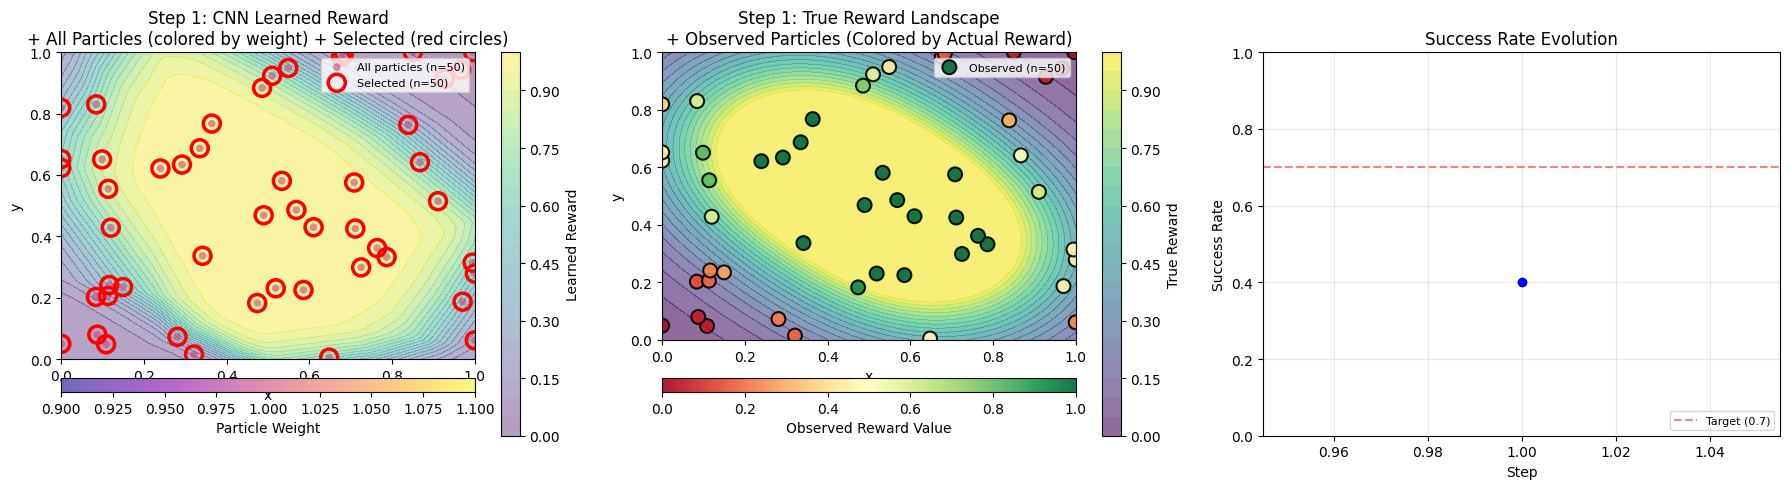

Step 1 Statistics:
  Total particles generated: 50
  Particles observed: 50
  Observed reward range: [0.013, 1.000]
  Average observed reward: 0.565
  Median observed reward: 0.484
  Std dev observed reward: 0.364
  Success count (reward > 0.7): 20/50
  Success rate: 0.400
    CNN input shape: (3, 2)
    CNN output shape before squeeze: (3, 1)
    CNN final output shape: (3,)
    Reward function input shape: (3, 2) -> (3, 2)
    Reward function output shape: (3,)
  CNN predictions on test points: [0.99896916 0.99532874 0.99339254]
  True rewards on test points: [1. 1. 1.]
  CNN error (MSE): 0.0000
  All particles weight range: [1.000, 1.000]
  All particles mean weight: 1.000
  All particles median weight: 1.000

Step 1, Budget remaining: 450
    CNN input shape: (1, 2)
    CNN output shape before squeeze: (1, 1)
    CNN final output shape: ()
    CNN input shape: (200, 2)
    CNN output shape before squeeze: (200, 1)
    CNN final output shape: (200,)
    CNN input shape: (1, 2)
    C

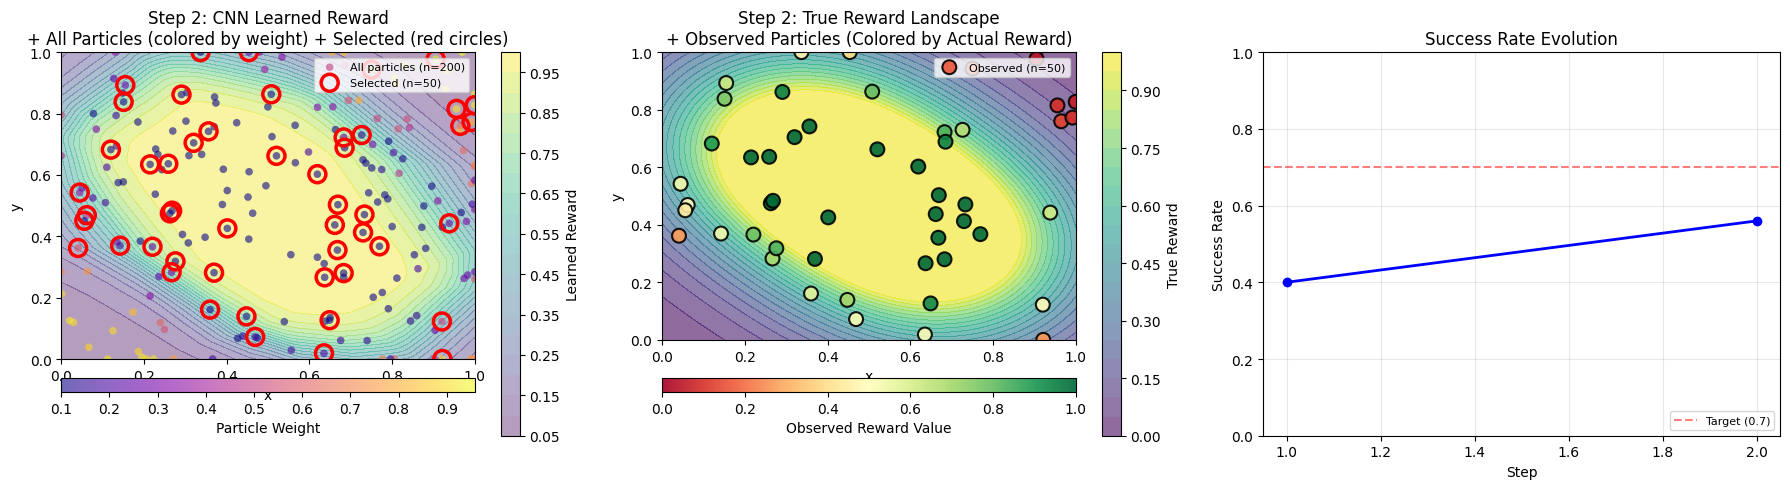

Step 2 Statistics:
  Total particles generated: 200
  Particles observed: 50
  Observed reward range: [0.038, 1.000]
  Average observed reward: 0.703
  Median observed reward: 0.791
  Std dev observed reward: 0.313
  Success count (reward > 0.7): 28/50
  Success rate: 0.560
    CNN input shape: (3, 2)
    CNN output shape before squeeze: (3, 1)
    CNN final output shape: (3,)
    Reward function input shape: (3, 2) -> (3, 2)
    Reward function output shape: (3,)
  CNN predictions on test points: [0.9962569  0.9904322  0.98831123]
  True rewards on test points: [1. 1. 1.]
  CNN error (MSE): 0.0001
  All particles weight range: [0.100, 0.958]
  All particles mean weight: 0.317
  All particles median weight: 0.157

Step 2, Budget remaining: 400
    CNN input shape: (1, 2)
    CNN output shape before squeeze: (1, 1)
    CNN final output shape: ()
    CNN input shape: (200, 2)
    CNN output shape before squeeze: (200, 1)
    CNN final output shape: (200,)
    CNN input shape: (1, 2)
    

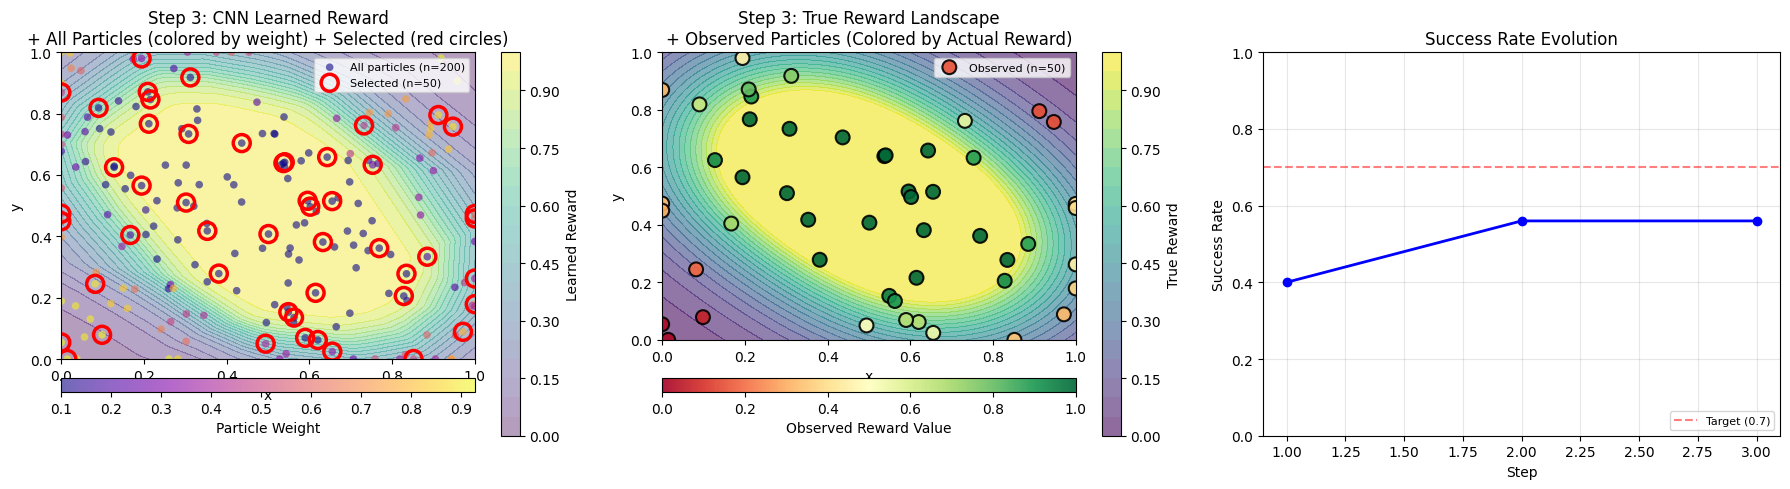

Step 3 Statistics:
  Total particles generated: 200
  Particles observed: 50
  Observed reward range: [0.015, 1.000]
  Average observed reward: 0.690
  Median observed reward: 0.842
  Std dev observed reward: 0.327
  Success count (reward > 0.7): 28/50
  Success rate: 0.560
    CNN input shape: (3, 2)
    CNN output shape before squeeze: (3, 1)
    CNN final output shape: (3,)
    Reward function input shape: (3, 2) -> (3, 2)
    Reward function output shape: (3,)
  CNN predictions on test points: [0.99804661 0.99475675 0.99310046]
  True rewards on test points: [1. 1. 1.]
  CNN error (MSE): 0.0000
  All particles weight range: [0.100, 0.928]
  All particles mean weight: 0.338
  All particles median weight: 0.187

Step 3, Budget remaining: 350
    CNN input shape: (1, 2)
    CNN output shape before squeeze: (1, 1)
    CNN final output shape: ()
    CNN input shape: (200, 2)
    CNN output shape before squeeze: (200, 1)
    CNN final output shape: (200,)
    CNN input shape: (1, 2)
    

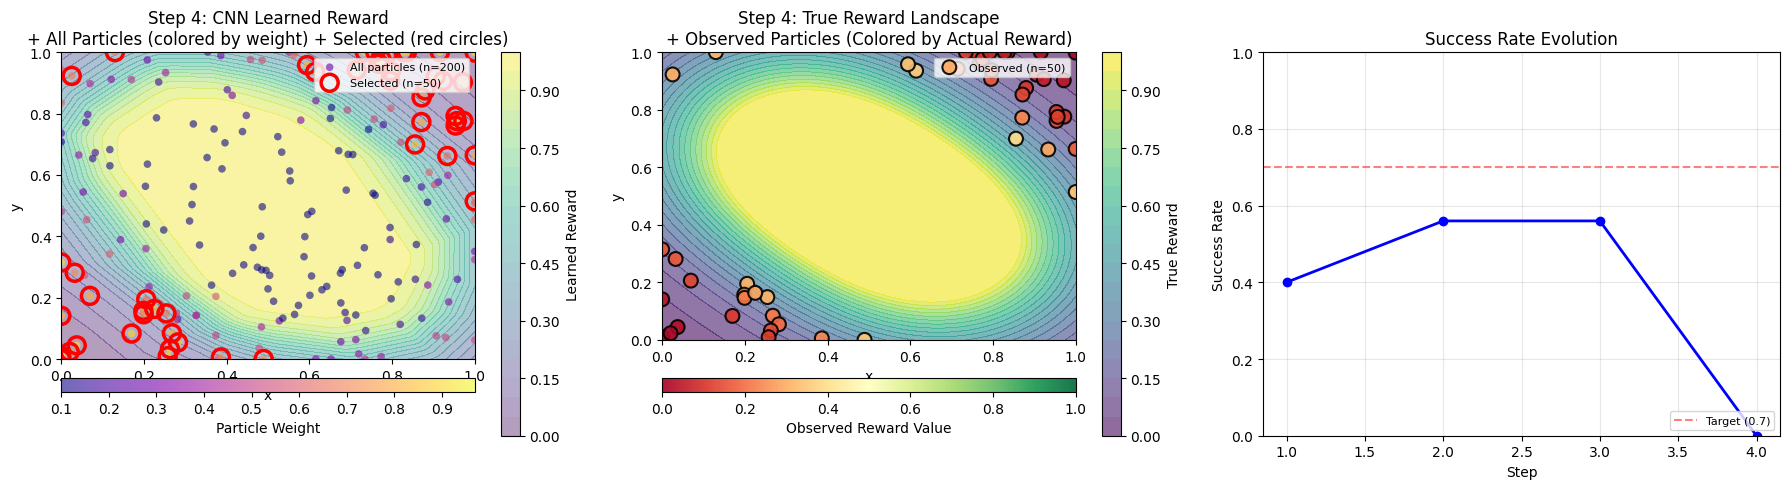

Step 4 Statistics:
  Total particles generated: 200
  Particles observed: 50
  Observed reward range: [0.013, 0.395]
  Average observed reward: 0.164
  Median observed reward: 0.136
  Std dev observed reward: 0.107
  Success count (reward > 0.7): 0/50
  Success rate: 0.000
    CNN input shape: (3, 2)
    CNN output shape before squeeze: (3, 1)
    CNN final output shape: (3,)
    Reward function input shape: (3, 2) -> (3, 2)
    Reward function output shape: (3,)
  CNN predictions on test points: [0.99812341 0.99590954 0.99298741]
  True rewards on test points: [1. 1. 1.]
  CNN error (MSE): 0.0000
  All particles weight range: [0.100, 0.969]
  All particles mean weight: 0.399
  All particles median weight: 0.319

Step 4, Budget remaining: 300
    CNN input shape: (1, 2)
    CNN output shape before squeeze: (1, 1)
    CNN final output shape: ()
    CNN input shape: (200, 2)
    CNN output shape before squeeze: (200, 1)
    CNN final output shape: (200,)
    CNN input shape: (1, 2)
    C

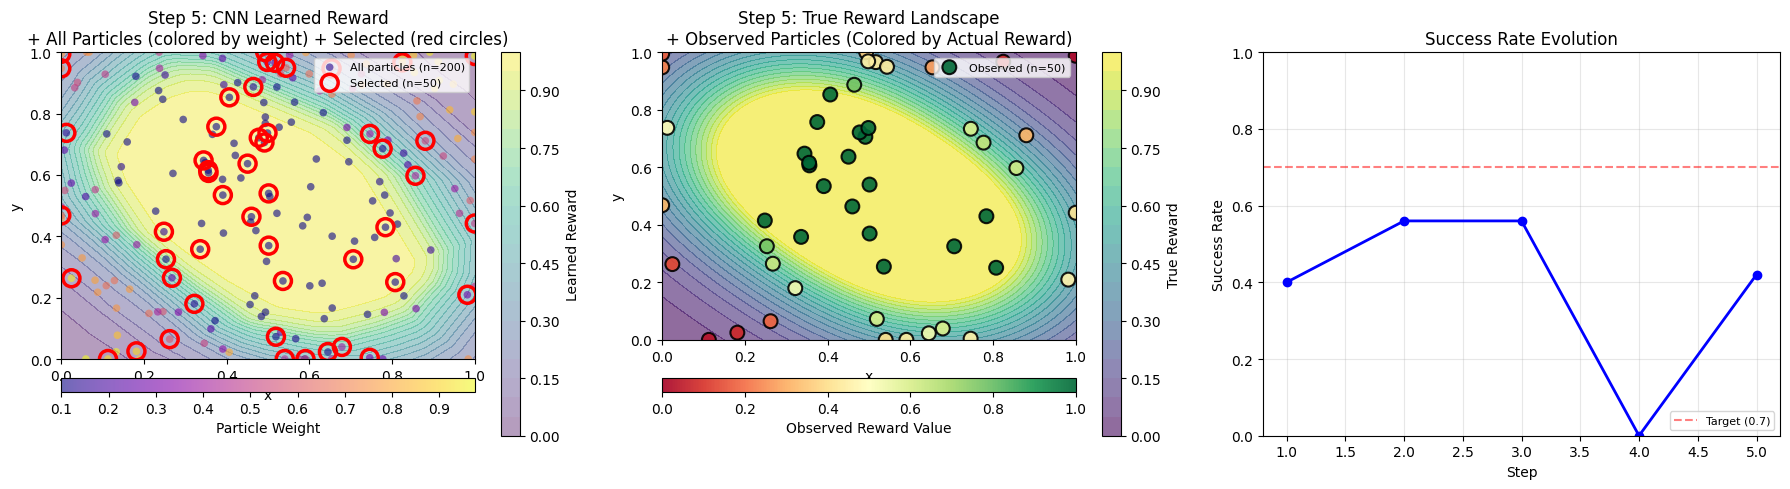

Step 5 Statistics:
  Total particles generated: 200
  Particles observed: 50
  Observed reward range: [0.015, 1.000]
  Average observed reward: 0.630
  Median observed reward: 0.601
  Std dev observed reward: 0.332
  Success count (reward > 0.7): 21/50
  Success rate: 0.420
    CNN input shape: (3, 2)
    CNN output shape before squeeze: (3, 1)
    CNN final output shape: (3,)
    Reward function input shape: (3, 2) -> (3, 2)
    Reward function output shape: (3,)
  CNN predictions on test points: [0.99928818 0.99656003 0.99548654]
  True rewards on test points: [1. 1. 1.]
  CNN error (MSE): 0.0000
  All particles weight range: [0.100, 0.975]
  All particles mean weight: 0.365
  All particles median weight: 0.260

Step 5, Budget remaining: 250
    CNN input shape: (1, 2)
    CNN output shape before squeeze: (1, 1)
    CNN final output shape: ()
    CNN input shape: (200, 2)
    CNN output shape before squeeze: (200, 1)
    CNN final output shape: (200,)
    CNN input shape: (1, 2)
    

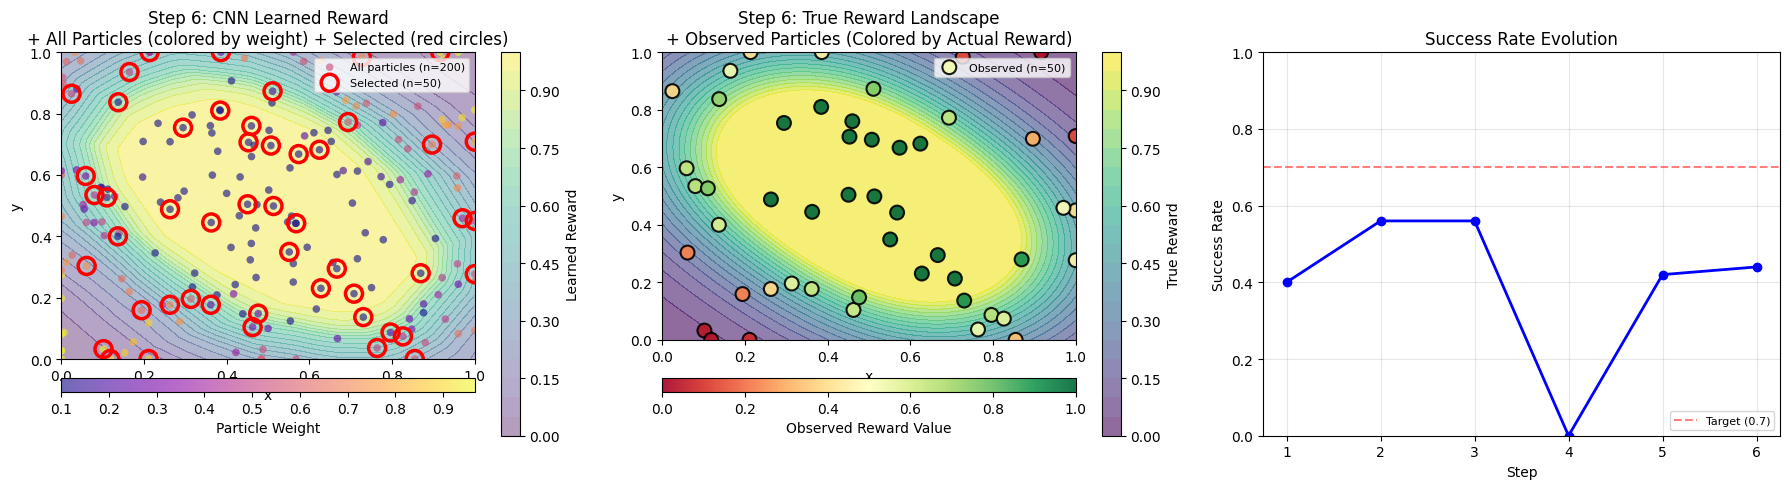

Step 6 Statistics:
  Total particles generated: 200
  Particles observed: 50
  Observed reward range: [0.028, 1.000]
  Average observed reward: 0.641
  Median observed reward: 0.639
  Std dev observed reward: 0.319
  Success count (reward > 0.7): 22/50
  Success rate: 0.440
    CNN input shape: (3, 2)
    CNN output shape before squeeze: (3, 1)
    CNN final output shape: (3,)
    Reward function input shape: (3, 2) -> (3, 2)
    Reward function output shape: (3,)
  CNN predictions on test points: [0.99924448 0.99605348 0.99750374]
  True rewards on test points: [1. 1. 1.]
  CNN error (MSE): 0.0000
  All particles weight range: [0.100, 0.966]
  All particles mean weight: 0.373
  All particles median weight: 0.281

Step 6, Budget remaining: 200
    CNN input shape: (1, 2)
    CNN output shape before squeeze: (1, 1)
    CNN final output shape: ()
    CNN input shape: (200, 2)
    CNN output shape before squeeze: (200, 1)
    CNN final output shape: (200,)
    CNN input shape: (1, 2)
    

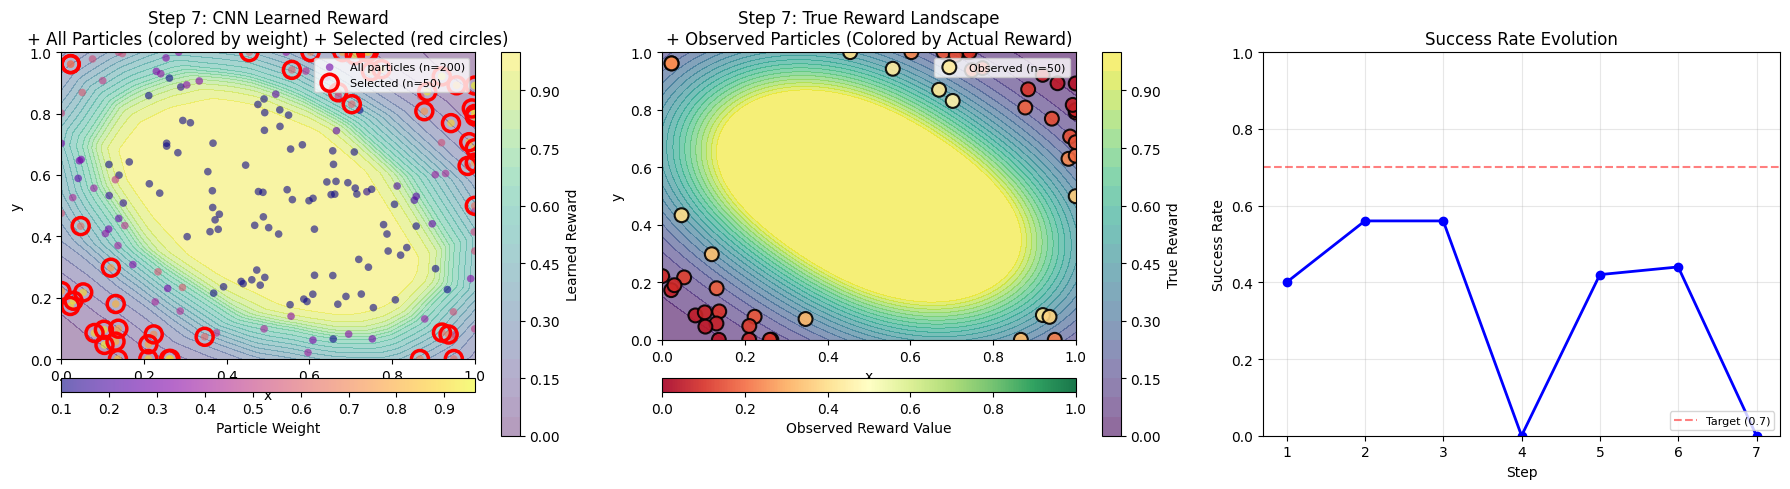

Step 7 Statistics:
  Total particles generated: 200
  Particles observed: 50
  Observed reward range: [0.035, 0.450]
  Average observed reward: 0.183
  Median observed reward: 0.146
  Std dev observed reward: 0.122
  Success count (reward > 0.7): 0/50
  Success rate: 0.000
    CNN input shape: (3, 2)
    CNN output shape before squeeze: (3, 1)
    CNN final output shape: (3,)
    Reward function input shape: (3, 2) -> (3, 2)
    Reward function output shape: (3,)
  CNN predictions on test points: [0.99927128 0.99634038 0.99815813]
  True rewards on test points: [1. 1. 1.]
  CNN error (MSE): 0.0000
  All particles weight range: [0.100, 0.964]
  All particles mean weight: 0.366
  All particles median weight: 0.293

Step 7, Budget remaining: 150
    CNN input shape: (1, 2)
    CNN output shape before squeeze: (1, 1)
    CNN final output shape: ()
    CNN input shape: (200, 2)
    CNN output shape before squeeze: (200, 1)
    CNN final output shape: (200,)
    CNN input shape: (1, 2)
    C

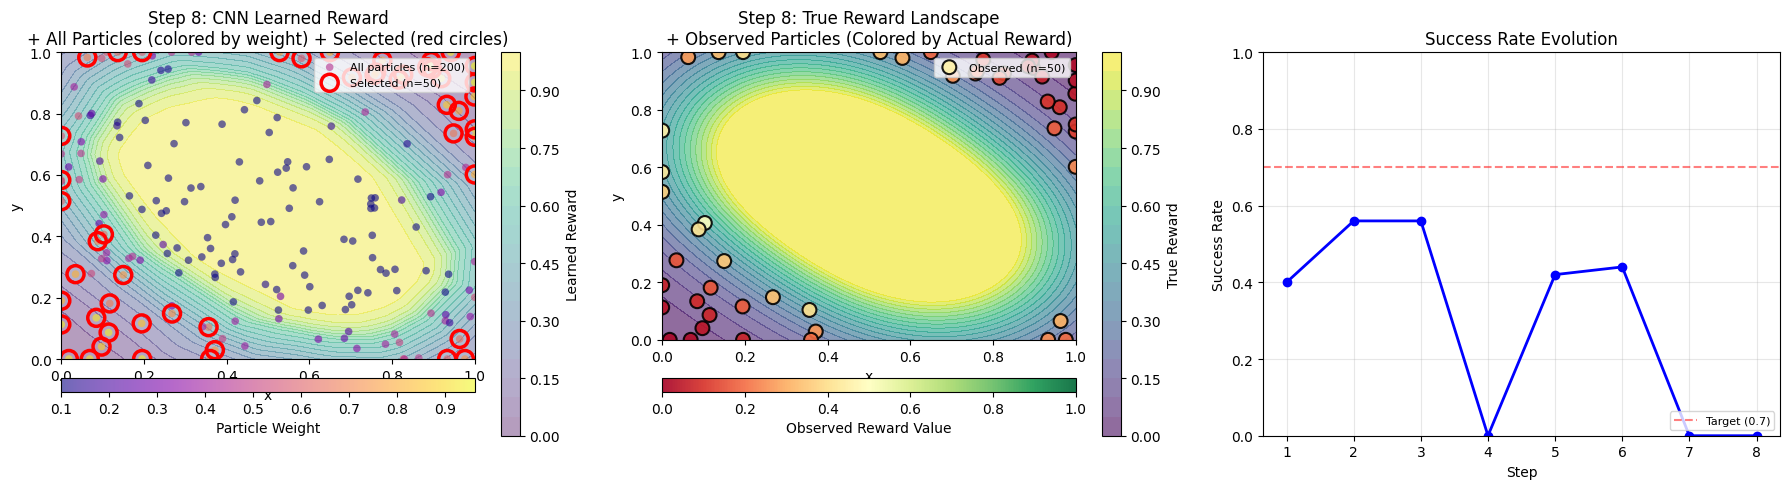

Step 8 Statistics:
  Total particles generated: 200
  Particles observed: 50
  Observed reward range: [0.015, 0.501]
  Average observed reward: 0.188
  Median observed reward: 0.164
  Std dev observed reward: 0.136
  Success count (reward > 0.7): 0/50
  Success rate: 0.000
    CNN input shape: (3, 2)
    CNN output shape before squeeze: (3, 1)
    CNN final output shape: (3,)
    Reward function input shape: (3, 2) -> (3, 2)
    Reward function output shape: (3,)
  CNN predictions on test points: [0.99926554 0.99590868 0.99790979]
  True rewards on test points: [1. 1. 1.]
  CNN error (MSE): 0.0000
  All particles weight range: [0.100, 0.961]
  All particles mean weight: 0.359
  All particles median weight: 0.261

Step 8, Budget remaining: 100
    CNN input shape: (1, 2)
    CNN output shape before squeeze: (1, 1)
    CNN final output shape: ()
    CNN input shape: (200, 2)
    CNN output shape before squeeze: (200, 1)
    CNN final output shape: (200,)
    CNN input shape: (1, 2)
    C

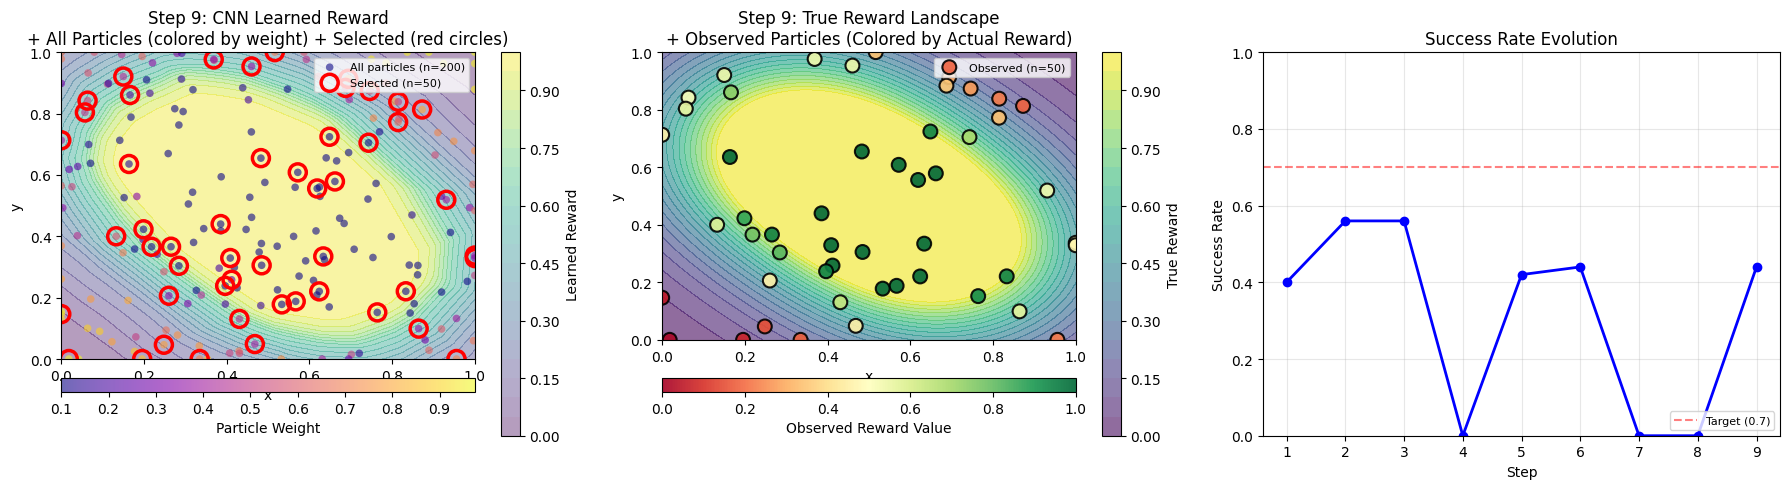

Step 9 Statistics:
  Total particles generated: 200
  Particles observed: 50
  Observed reward range: [0.015, 1.000]
  Average observed reward: 0.632
  Median observed reward: 0.571
  Std dev observed reward: 0.319
  Success count (reward > 0.7): 22/50
  Success rate: 0.440
    CNN input shape: (3, 2)
    CNN output shape before squeeze: (3, 1)
    CNN final output shape: (3,)
    Reward function input shape: (3, 2) -> (3, 2)
    Reward function output shape: (3,)
  CNN predictions on test points: [0.99976438 0.99789187 0.99865337]
  True rewards on test points: [1. 1. 1.]
  CNN error (MSE): 0.0000
  All particles weight range: [0.100, 0.975]
  All particles mean weight: 0.370
  All particles median weight: 0.271

Step 9, Budget remaining: 50
    CNN input shape: (1, 2)
    CNN output shape before squeeze: (1, 1)
    CNN final output shape: ()
    CNN input shape: (200, 2)
    CNN output shape before squeeze: (200, 1)
    CNN final output shape: (200,)
    CNN input shape: (1, 2)
    C

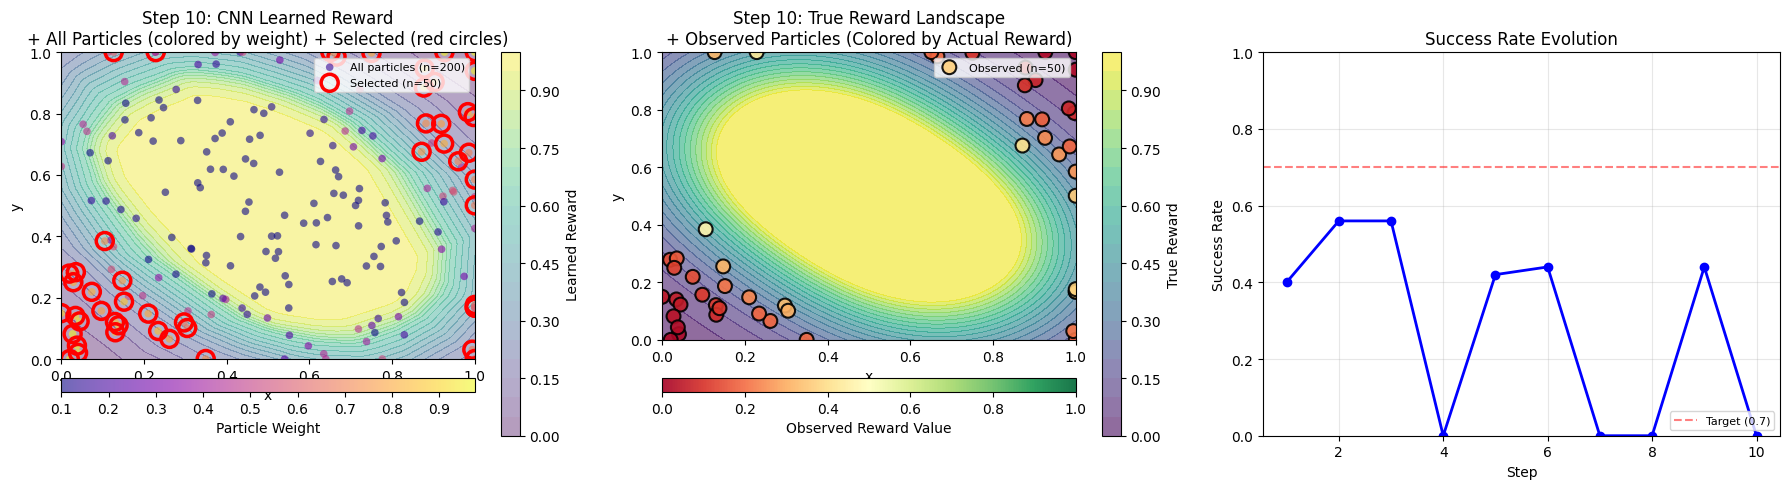

Step 10 Statistics:
  Total particles generated: 200
  Particles observed: 50
  Observed reward range: [0.013, 0.464]
  Average observed reward: 0.182
  Median observed reward: 0.174
  Std dev observed reward: 0.121
  Success count (reward > 0.7): 0/50
  Success rate: 0.000
    CNN input shape: (3, 2)
    CNN output shape before squeeze: (3, 1)
    CNN final output shape: (3,)
    Reward function input shape: (3, 2) -> (3, 2)
    Reward function output shape: (3,)
  CNN predictions on test points: [0.99970114 0.9979713  0.99837159]
  True rewards on test points: [1. 1. 1.]
  CNN error (MSE): 0.0000
  All particles weight range: [0.100, 0.975]
  All particles mean weight: 0.354
  All particles median weight: 0.197


THREE PEAKS RESULTS SUMMARY
Total steps completed: 10
Final success rate: 0.000
Average success rate: 0.282


PART 2: FOUR OPTIMA (QUADRANT) REWARD FUNCTION
CONTINUING WITH TRAINED NEURAL NETWORK FROM PART 1

  Using pre-trained neural network (continuing training)
Step 0 [C

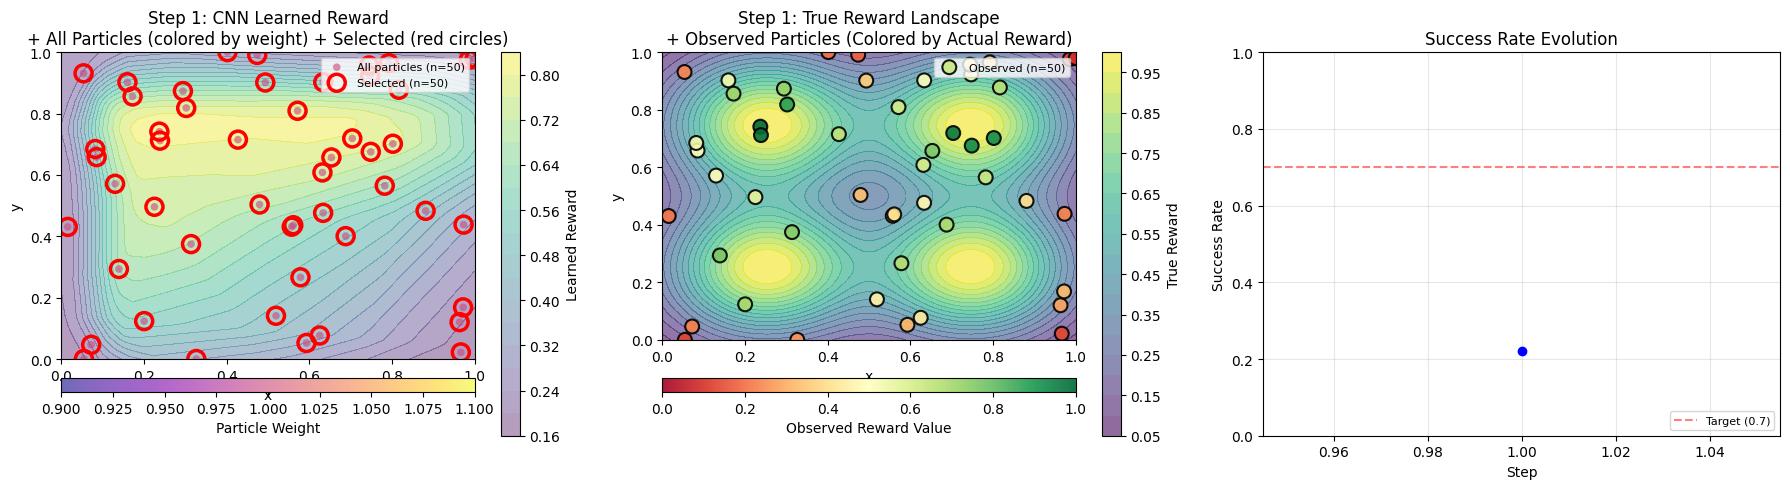

Step 1 Statistics:
  Total particles generated: 50
  Particles observed: 50
  Observed reward range: [0.100, 1.000]
  Average observed reward: 0.509
  Median observed reward: 0.502
  Std dev observed reward: 0.245
  Success count (reward > 0.7): 11/50
  Success rate: 0.220
    CNN input shape: (3, 2)
    CNN output shape before squeeze: (3, 1)
    CNN final output shape: (3,)
    Four optima reward function input shape: (3, 2) -> (3, 2)
    Four optima reward function output shape: (3,)
  CNN predictions on test points: [0.68368882 0.80002422 0.46418202]
  True rewards on test points: [0.32833999 0.93828631 0.93828631]
  CNN error (MSE): 0.1234
  All particles weight range: [1.000, 1.000]
  All particles mean weight: 1.000
  All particles median weight: 1.000

Step 1, Budget remaining: 450
    CNN input shape: (1, 2)
    CNN output shape before squeeze: (1, 1)
    CNN final output shape: ()
    CNN input shape: (200, 2)
    CNN output shape before squeeze: (200, 1)
    CNN final output

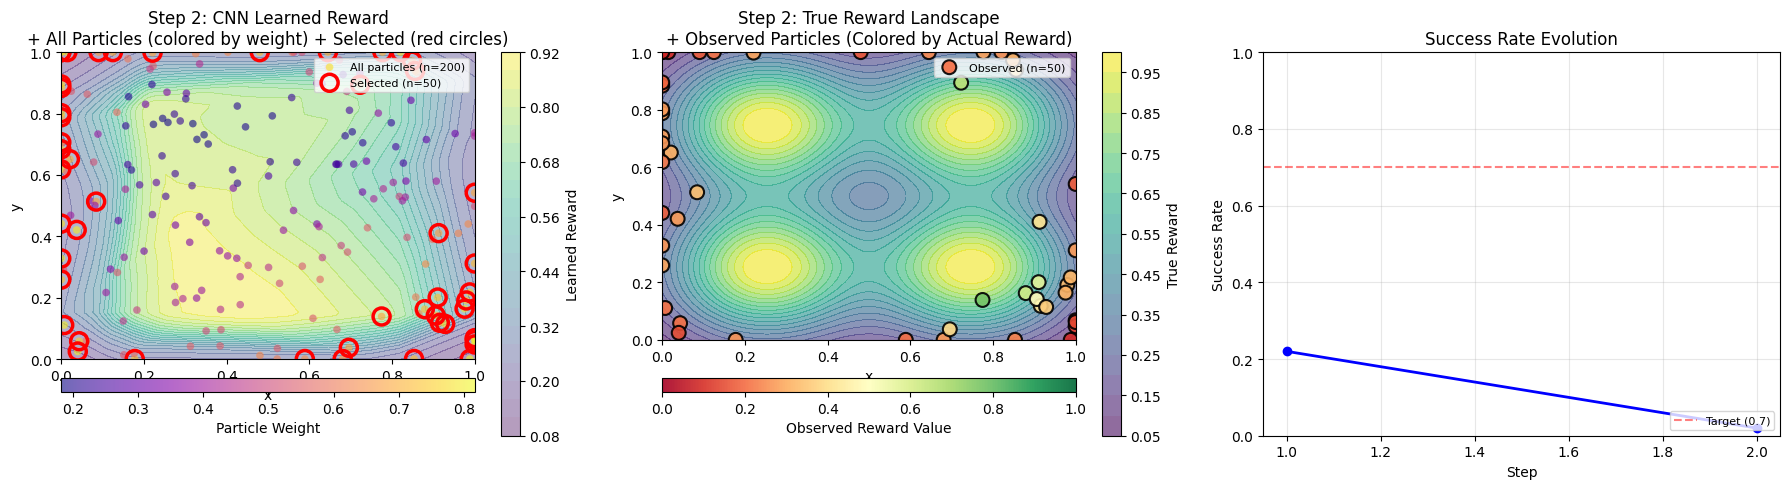

Step 2 Statistics:
  Total particles generated: 200
  Particles observed: 50
  Observed reward range: [0.082, 0.774]
  Average observed reward: 0.281
  Median observed reward: 0.268
  Std dev observed reward: 0.143
  Success count (reward > 0.7): 1/50
  Success rate: 0.020
    CNN input shape: (3, 2)
    CNN output shape before squeeze: (3, 1)
    CNN final output shape: (3,)
    Four optima reward function input shape: (3, 2) -> (3, 2)
    Four optima reward function output shape: (3,)
  CNN predictions on test points: [0.79331966 0.81776045 0.77133247]
  True rewards on test points: [0.32833999 0.93828631 0.93828631]
  CNN error (MSE): 0.0862
  All particles weight range: [0.182, 0.817]
  All particles mean weight: 0.478
  All particles median weight: 0.472

Step 2, Budget remaining: 400
    CNN input shape: (1, 2)
    CNN output shape before squeeze: (1, 1)
    CNN final output shape: ()
    CNN input shape: (200, 2)
    CNN output shape before squeeze: (200, 1)
    CNN final output

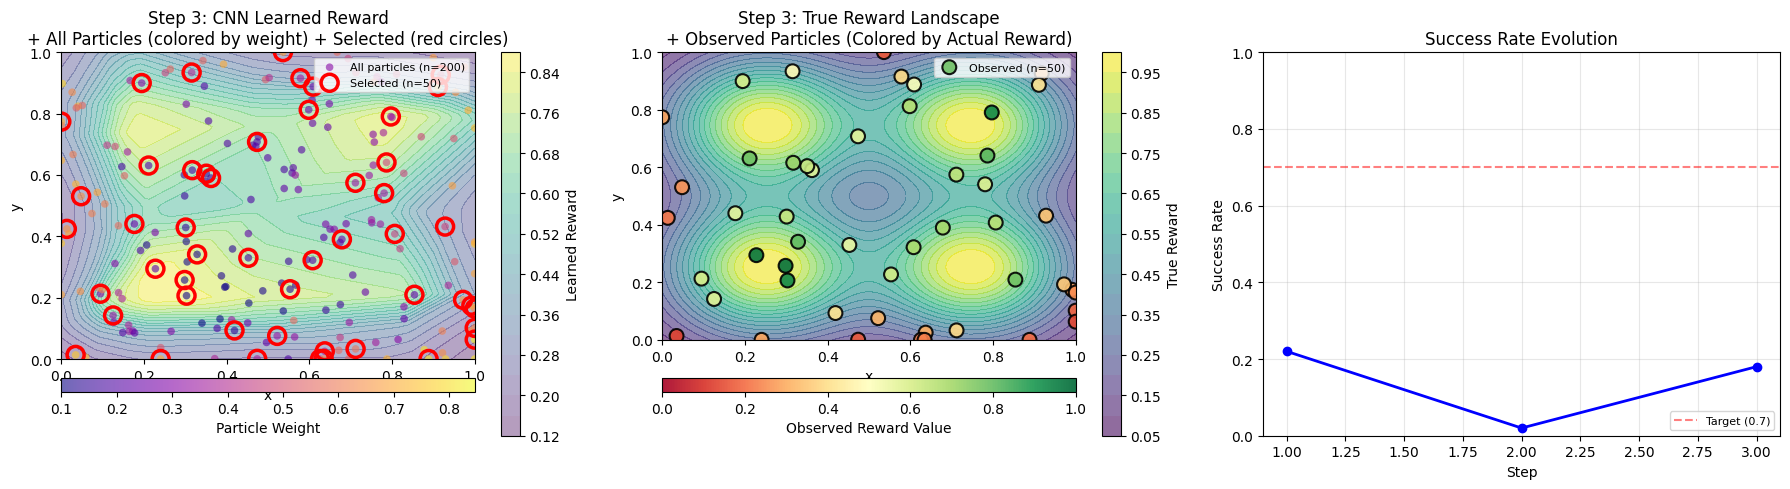

Step 3 Statistics:
  Total particles generated: 200
  Particles observed: 50
  Observed reward range: [0.129, 0.978]
  Average observed reward: 0.497
  Median observed reward: 0.534
  Std dev observed reward: 0.238
  Success count (reward > 0.7): 9/50
  Success rate: 0.180
    CNN input shape: (3, 2)
    CNN output shape before squeeze: (3, 1)
    CNN final output shape: (3,)
    Four optima reward function input shape: (3, 2) -> (3, 2)
    Four optima reward function output shape: (3,)
  CNN predictions on test points: [0.63554462 0.75428198 0.68399961]
  True rewards on test points: [0.32833999 0.93828631 0.93828631]
  CNN error (MSE): 0.0643
  All particles weight range: [0.100, 0.846]
  All particles mean weight: 0.392
  All particles median weight: 0.349

Step 3, Budget remaining: 350
    CNN input shape: (1, 2)
    CNN output shape before squeeze: (1, 1)
    CNN final output shape: ()
    CNN input shape: (200, 2)
    CNN output shape before squeeze: (200, 1)
    CNN final output

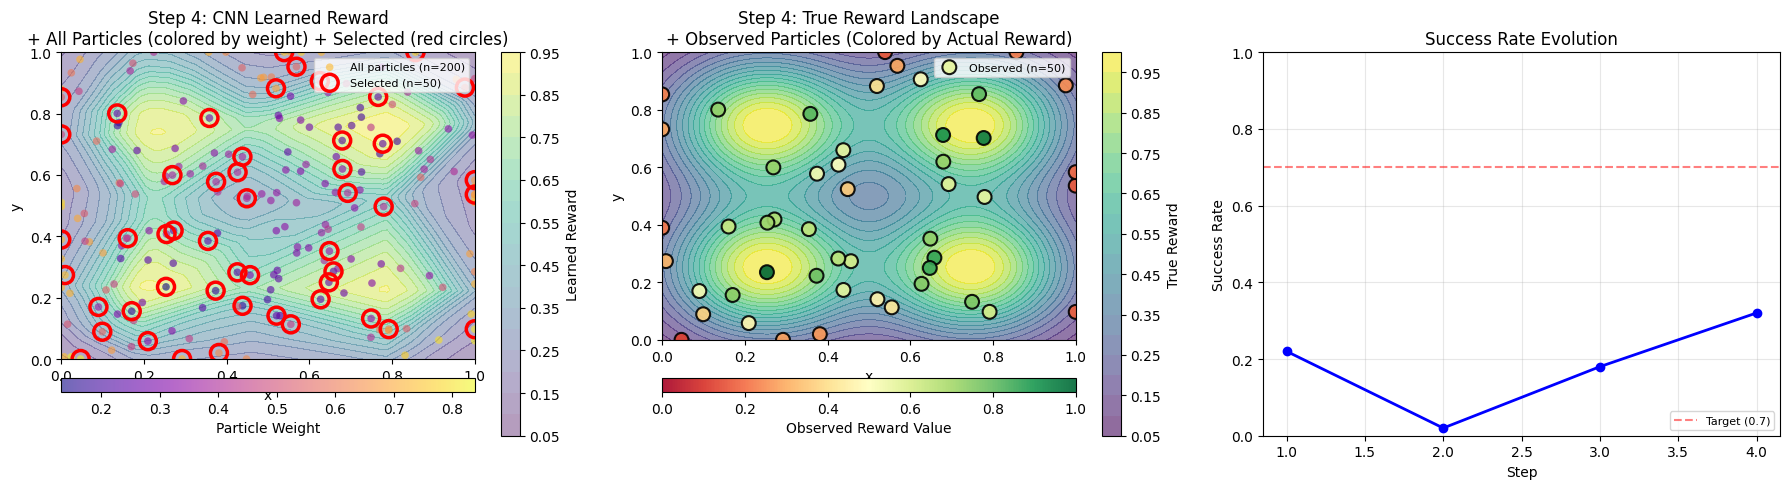

Step 4 Statistics:
  Total particles generated: 200
  Particles observed: 50
  Observed reward range: [0.125, 1.000]
  Average observed reward: 0.535
  Median observed reward: 0.563
  Std dev observed reward: 0.237
  Success count (reward > 0.7): 16/50
  Success rate: 0.320
    CNN input shape: (3, 2)
    CNN output shape before squeeze: (3, 1)
    CNN final output shape: (3,)
    Four optima reward function input shape: (3, 2) -> (3, 2)
    Four optima reward function output shape: (3,)
  CNN predictions on test points: [0.37717426 0.83021674 0.79876014]
  True rewards on test points: [0.32833999 0.93828631 0.93828631]
  CNN error (MSE): 0.0112
  All particles weight range: [0.132, 0.838]
  All particles mean weight: 0.445
  All particles median weight: 0.396

Step 4, Budget remaining: 300
    CNN input shape: (1, 2)
    CNN output shape before squeeze: (1, 1)
    CNN final output shape: ()
    CNN input shape: (200, 2)
    CNN output shape before squeeze: (200, 1)
    CNN final outpu

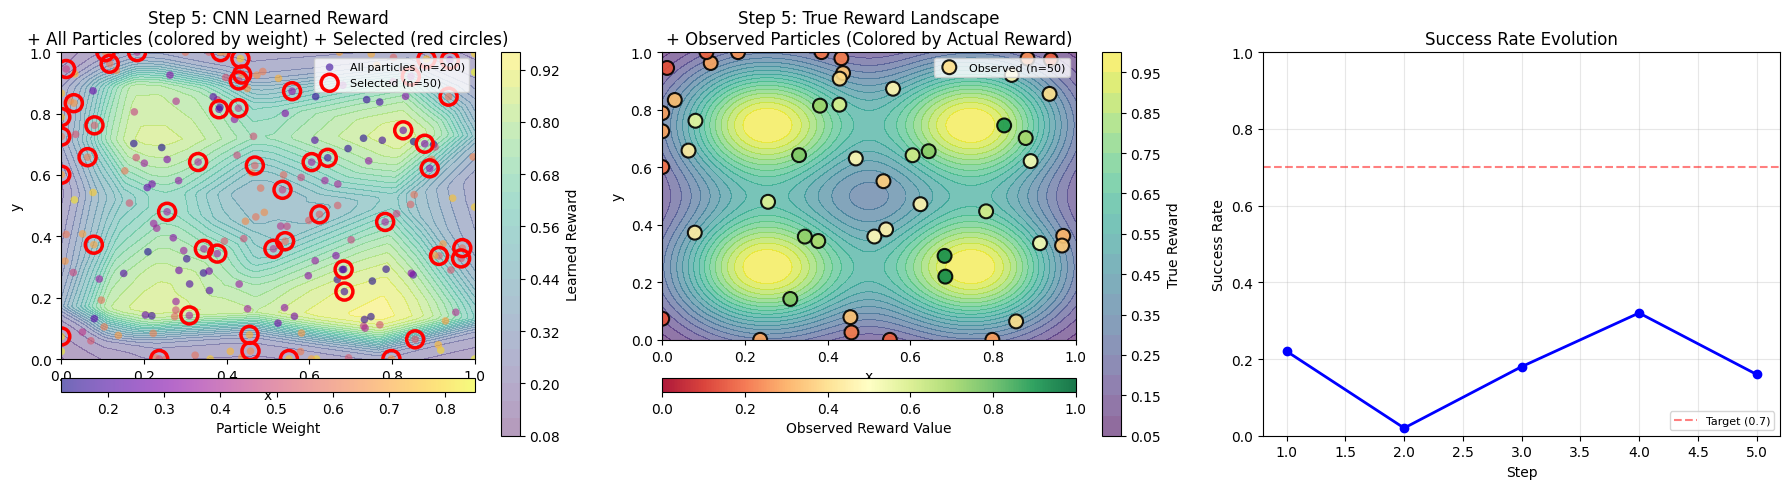

Step 5 Statistics:
  Total particles generated: 200
  Particles observed: 50
  Observed reward range: [0.150, 0.927]
  Average observed reward: 0.449
  Median observed reward: 0.420
  Std dev observed reward: 0.210
  Success count (reward > 0.7): 8/50
  Success rate: 0.160
    CNN input shape: (3, 2)
    CNN output shape before squeeze: (3, 1)
    CNN final output shape: (3,)
    Four optima reward function input shape: (3, 2) -> (3, 2)
    Four optima reward function output shape: (3,)
  CNN predictions on test points: [0.41531585 0.82043496 0.81202926]
  True rewards on test points: [0.32833999 0.93828631 0.93828631]
  CNN error (MSE): 0.0125
  All particles weight range: [0.117, 0.853]
  All particles mean weight: 0.475
  All particles median weight: 0.498

Step 5, Budget remaining: 250
    CNN input shape: (1, 2)
    CNN output shape before squeeze: (1, 1)
    CNN final output shape: ()
    CNN input shape: (200, 2)
    CNN output shape before squeeze: (200, 1)
    CNN final output

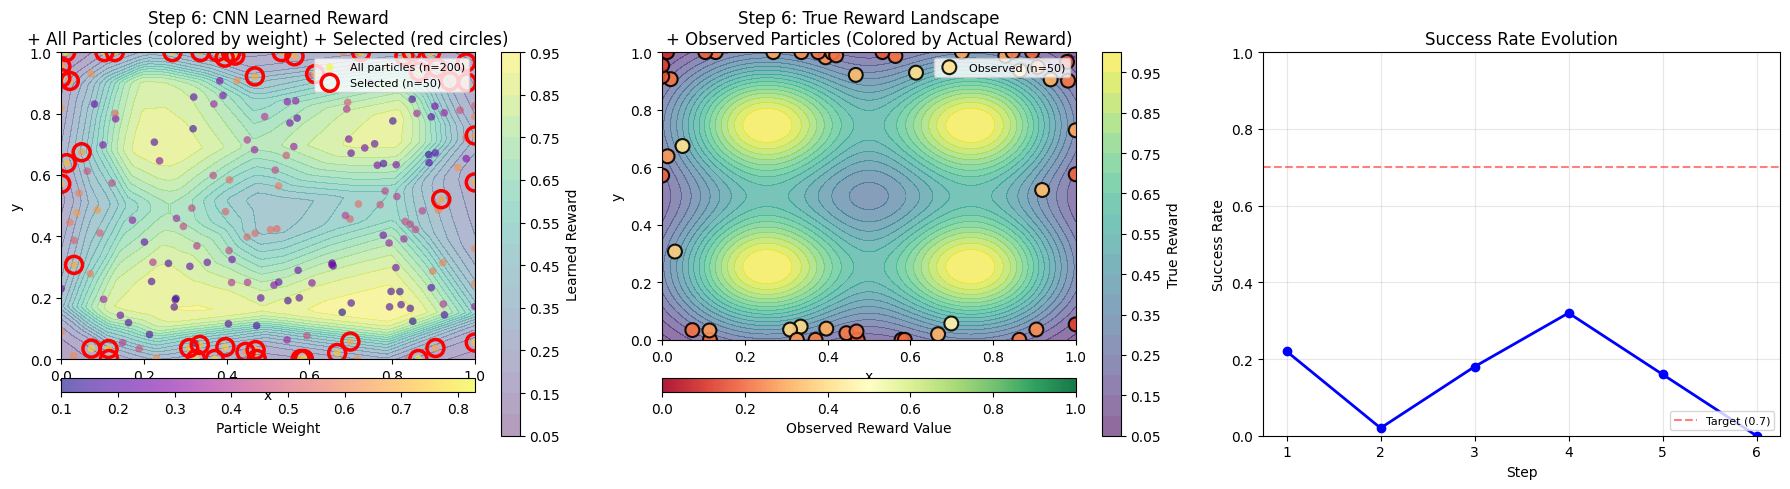

Step 6 Statistics:
  Total particles generated: 200
  Particles observed: 50
  Observed reward range: [0.092, 0.459]
  Average observed reward: 0.250
  Median observed reward: 0.228
  Std dev observed reward: 0.079
  Success count (reward > 0.7): 0/50
  Success rate: 0.000
    CNN input shape: (3, 2)
    CNN output shape before squeeze: (3, 1)
    CNN final output shape: (3,)
    Four optima reward function input shape: (3, 2) -> (3, 2)
    Four optima reward function output shape: (3,)
  CNN predictions on test points: [0.42713419 0.87936072 0.80893168]
  True rewards on test points: [0.32833999 0.93828631 0.93828631]
  CNN error (MSE): 0.0100
  All particles weight range: [0.100, 0.830]
  All particles mean weight: 0.462
  All particles median weight: 0.446

Step 6, Budget remaining: 200
    CNN input shape: (1, 2)
    CNN output shape before squeeze: (1, 1)
    CNN final output shape: ()
    CNN input shape: (200, 2)
    CNN output shape before squeeze: (200, 1)
    CNN final output

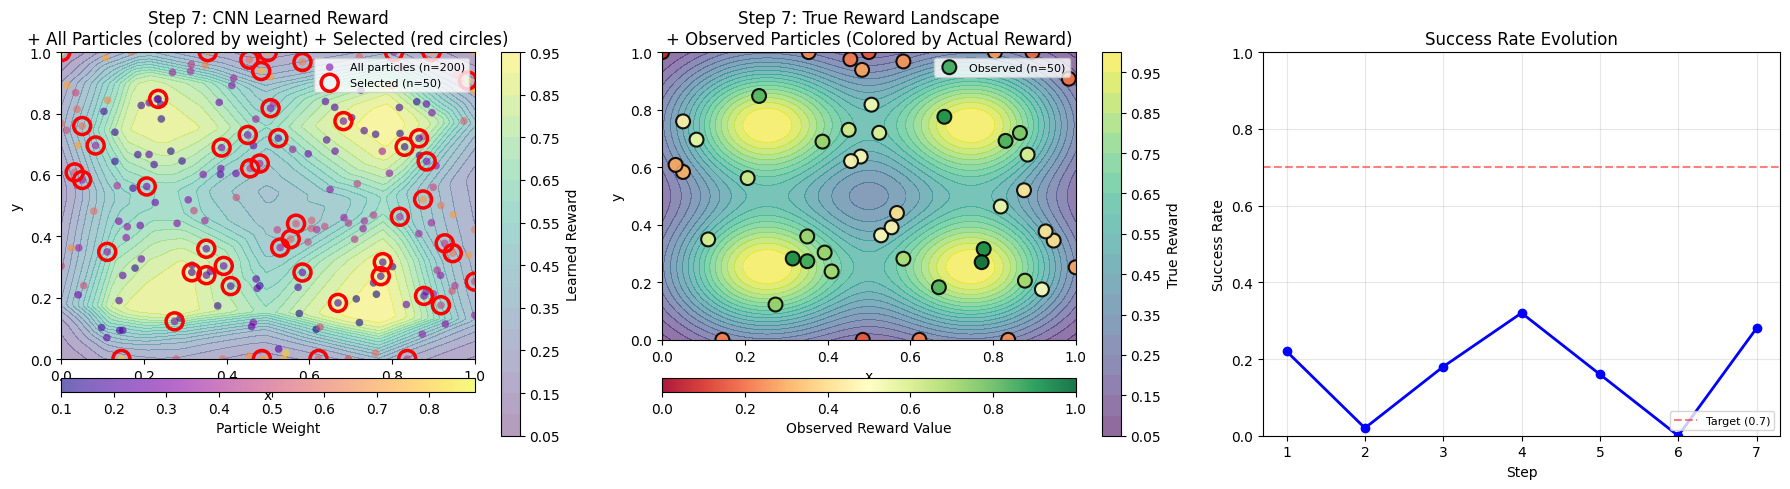

Step 7 Statistics:
  Total particles generated: 200
  Particles observed: 50
  Observed reward range: [0.082, 0.996]
  Average observed reward: 0.513
  Median observed reward: 0.496
  Std dev observed reward: 0.242
  Success count (reward > 0.7): 14/50
  Success rate: 0.280
    CNN input shape: (3, 2)
    CNN output shape before squeeze: (3, 1)
    CNN final output shape: (3,)
    Four optima reward function input shape: (3, 2) -> (3, 2)
    Four optima reward function output shape: (3,)
  CNN predictions on test points: [0.40343702 0.8145297  0.83033756]
  True rewards on test points: [0.32833999 0.93828631 0.93828631]
  CNN error (MSE): 0.0109
  All particles weight range: [0.100, 0.886]
  All particles mean weight: 0.383
  All particles median weight: 0.351

Step 7, Budget remaining: 150
    CNN input shape: (1, 2)
    CNN output shape before squeeze: (1, 1)
    CNN final output shape: ()
    CNN input shape: (200, 2)
    CNN output shape before squeeze: (200, 1)
    CNN final outpu

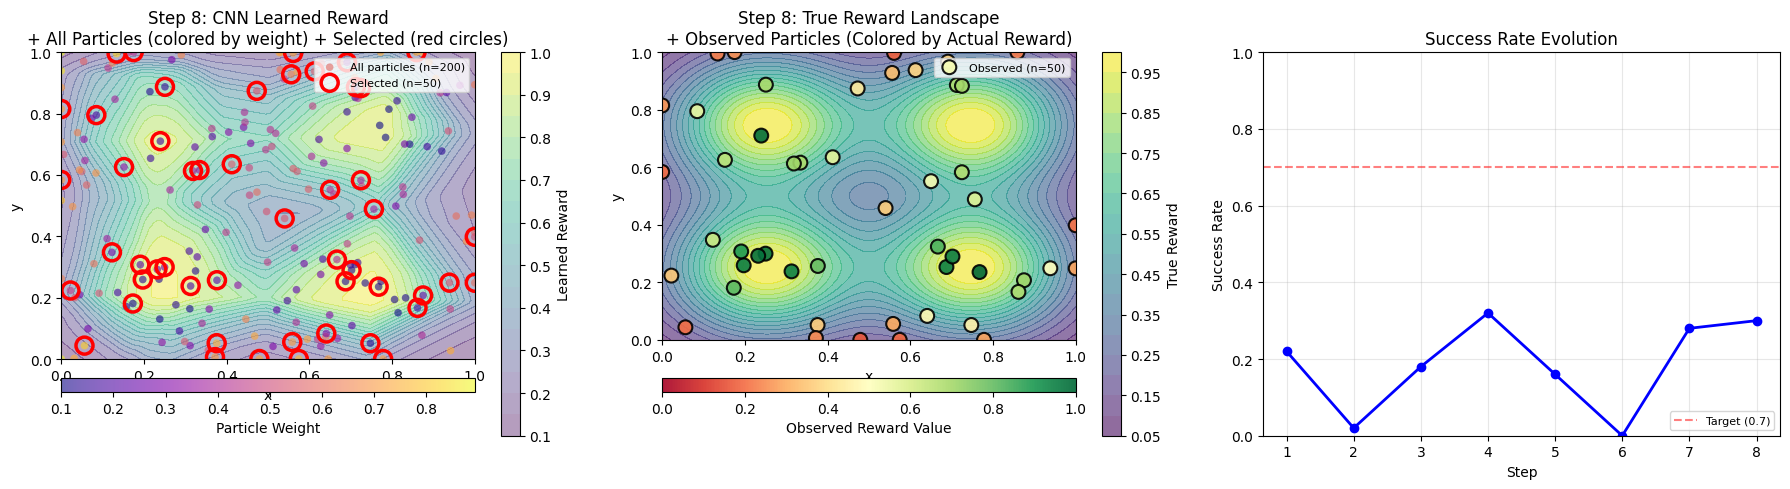

Step 8 Statistics:
  Total particles generated: 200
  Particles observed: 50
  Observed reward range: [0.166, 1.000]
  Average observed reward: 0.548
  Median observed reward: 0.544
  Std dev observed reward: 0.269
  Success count (reward > 0.7): 15/50
  Success rate: 0.300
    CNN input shape: (3, 2)
    CNN output shape before squeeze: (3, 1)
    CNN final output shape: (3,)
    Four optima reward function input shape: (3, 2) -> (3, 2)
    Four optima reward function output shape: (3,)
  CNN predictions on test points: [0.35508442 0.86536954 0.91371035]
  True rewards on test points: [0.32833999 0.93828631 0.93828631]
  CNN error (MSE): 0.0022
  All particles weight range: [0.100, 0.893]
  All particles mean weight: 0.421
  All particles median weight: 0.412

Step 8, Budget remaining: 100
    CNN input shape: (1, 2)
    CNN output shape before squeeze: (1, 1)
    CNN final output shape: ()
    CNN input shape: (200, 2)
    CNN output shape before squeeze: (200, 1)
    CNN final outpu

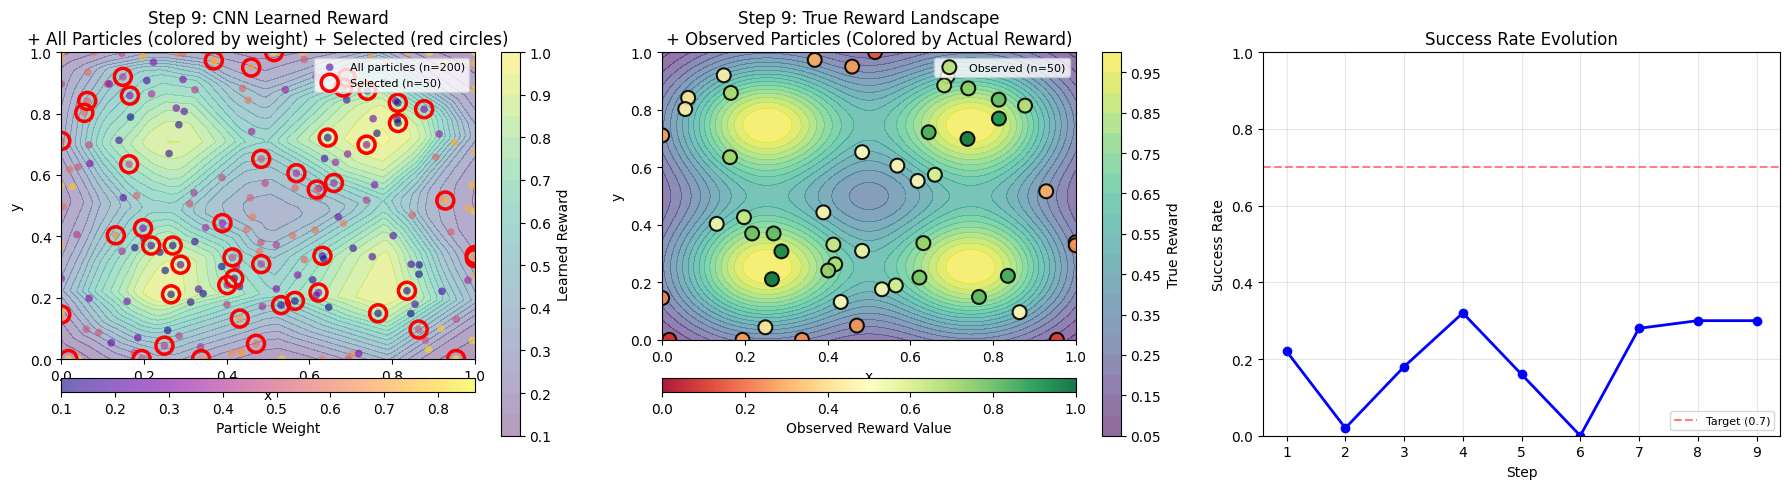

Step 9 Statistics:
  Total particles generated: 200
  Particles observed: 50
  Observed reward range: [0.097, 0.977]
  Average observed reward: 0.548
  Median observed reward: 0.544
  Std dev observed reward: 0.234
  Success count (reward > 0.7): 15/50
  Success rate: 0.300
    CNN input shape: (3, 2)
    CNN output shape before squeeze: (3, 1)
    CNN final output shape: (3,)
    Four optima reward function input shape: (3, 2) -> (3, 2)
    Four optima reward function output shape: (3,)
  CNN predictions on test points: [0.32200447 0.89218958 0.83931006]
  True rewards on test points: [0.32833999 0.93828631 0.93828631]
  CNN error (MSE): 0.0040
  All particles weight range: [0.100, 0.868]
  All particles mean weight: 0.438
  All particles median weight: 0.430

Step 9, Budget remaining: 50
    CNN input shape: (1, 2)
    CNN output shape before squeeze: (1, 1)
    CNN final output shape: ()
    CNN input shape: (200, 2)
    CNN output shape before squeeze: (200, 1)
    CNN final output

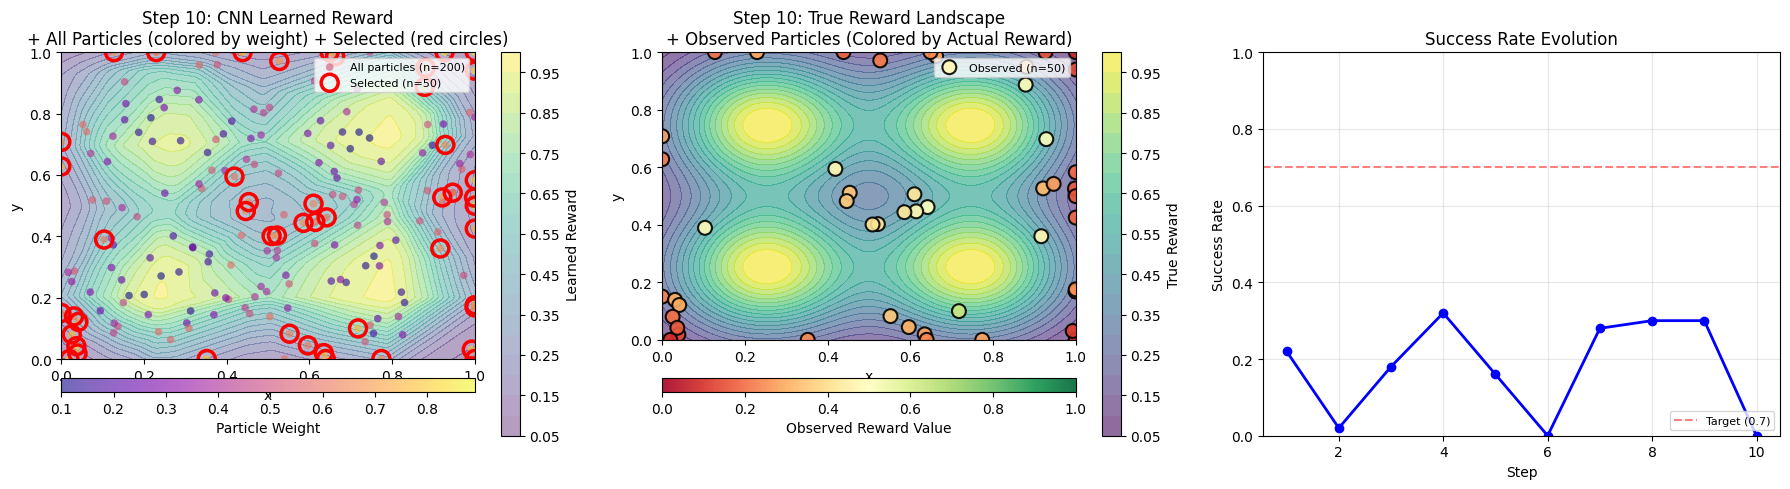

Step 10 Statistics:
  Total particles generated: 200
  Particles observed: 50
  Observed reward range: [0.082, 0.632]
  Average observed reward: 0.291
  Median observed reward: 0.279
  Std dev observed reward: 0.127
  Success count (reward > 0.7): 0/50
  Success rate: 0.000
    CNN input shape: (3, 2)
    CNN output shape before squeeze: (3, 1)
    CNN final output shape: (3,)
    Four optima reward function input shape: (3, 2) -> (3, 2)
    Four optima reward function output shape: (3,)
  CNN predictions on test points: [0.33803865 0.9130392  0.9081995 ]
  True rewards on test points: [0.32833999 0.93828631 0.93828631]
  CNN error (MSE): 0.0005
  All particles weight range: [0.100, 0.891]
  All particles mean weight: 0.449
  All particles median weight: 0.456


FOUR OPTIMA RESULTS SUMMARY
Total steps completed: 10
Final success rate: 0.000
Average success rate: 0.178


COMPARISON


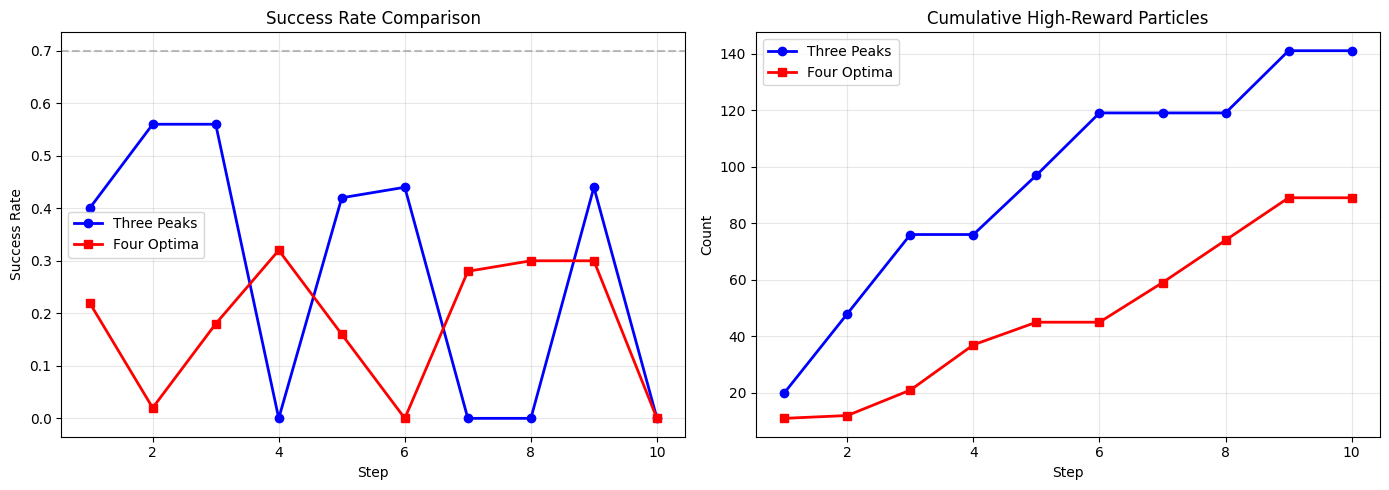


Three Peaks - Final success rate: 0.000
Four Optima - Final success rate: 0.000


In [34]:
# Set parameters
k_observe = 50
B = 500
n_particles = 200

print("="*80)
print("RUNNING ALGORITHM ON BOTH REWARD FUNCTIONS")
print("WITH PERSISTENT NEURAL NETWORK")
print("="*80)

# ============================================================================
# RUN 1: Three Peaks Reward Function
# ============================================================================
print("\n" + "="*80)
print("PART 1: THREE PEAKS REWARD FUNCTION")
print("="*80 + "\n")

reward_function_3peaks = create_reward_landscape

# Run the algorithm (network starts from scratch)
results_3peaks = budget_constrained_diffusion(
    k_observe, B, n_particles, 
    reward_fn=reward_function_3peaks
)

all_particles_3peaks, all_weights_3peaks, all_observed_particles_3peaks, \
    all_observed_rewards_3peaks, success_rates_3peaks, \
    trained_network, trained_params, trained_opt_state = results_3peaks

print("\n" + "="*80)
print("THREE PEAKS RESULTS SUMMARY")
print("="*80)
print(f"Total steps completed: {len(success_rates_3peaks)}")
print(f"Final success rate: {success_rates_3peaks[-1]:.3f}")
print(f"Average success rate: {jnp.mean(jnp.array(success_rates_3peaks)):.3f}")
print("="*80 + "\n")

# ============================================================================
# RUN 2: Four Optima (Quadrant) Reward Function
# ============================================================================
print("\n" + "="*80)
print("PART 2: FOUR OPTIMA (QUADRANT) REWARD FUNCTION")
print("CONTINUING WITH TRAINED NEURAL NETWORK FROM PART 1")
print("="*80 + "\n")

reward_function_4optima = create_four_optima_reward_landscape

# Run the algorithm WITH THE TRAINED NETWORK from Run 1
results_4optima = budget_constrained_diffusion(
    k_observe, B, n_particles, 
    reward_fn=reward_function_4optima,
    network=trained_network,  # Use trained network
    network_params=trained_params,  # Use trained params
    opt_state=trained_opt_state  # Use trained optimizer state
)

all_particles_4optima, all_weights_4optima, all_observed_particles_4optima, \
    all_observed_rewards_4optima, success_rates_4optima, \
    final_network, final_params, final_opt_state = results_4optima

print("\n" + "="*80)
print("FOUR OPTIMA RESULTS SUMMARY")
print("="*80)
print(f"Total steps completed: {len(success_rates_4optima)}")
print(f"Final success rate: {success_rates_4optima[-1]:.3f}")
print(f"Average success rate: {jnp.mean(jnp.array(success_rates_4optima)):.3f}")
print("="*80 + "\n")

# ============================================================================
# COMPARISON
# ============================================================================
print("\n" + "="*80)
print("COMPARISON")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Success rates
axes[0].plot(range(1, len(success_rates_3peaks) + 1), success_rates_3peaks, 
            'b-o', linewidth=2, markersize=6, label='Three Peaks')
axes[0].plot(range(1, len(success_rates_4optima) + 1), success_rates_4optima, 
            'r-s', linewidth=2, markersize=6, label='Four Optima')
axes[0].axhline(y=0.7, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Success Rate Comparison')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Success Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative success
cumsum_3 = [jnp.sum(r > 0.7) for r in all_observed_rewards_3peaks]
cumsum_4 = [jnp.sum(r > 0.7) for r in all_observed_rewards_4optima]
cumulative_3 = jnp.cumsum(jnp.array(cumsum_3))
cumulative_4 = jnp.cumsum(jnp.array(cumsum_4))

axes[1].plot(range(1, len(cumulative_3) + 1), cumulative_3, 
            'b-o', linewidth=2, markersize=6, label='Three Peaks')
axes[1].plot(range(1, len(cumulative_4) + 1), cumulative_4, 
            'r-s', linewidth=2, markersize=6, label='Four Optima')
axes[1].set_title('Cumulative High-Reward Particles')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nThree Peaks - Final success rate: {success_rates_3peaks[-1]:.3f}")
print(f"Four Optima - Final success rate: {success_rates_4optima[-1]:.3f}")